In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.ticker import FormatStrFormatter

from dae_finder import PolyFeatureMatrix
import Comparison
from Recover_Model import Recover_Model_sindy
import importlib
from Basis import OrthogonalLibrary, Monomials, standardize_columns, normalization
from Sample_Analysis import create_initial_conditions, sampling, distribution_test
from Base_test import CRN, Lotka_Volterra

/Users/yuxiangfeng/Desktop/SINDy/3.Dependence/illposed_env/lib/python3.12/site-packages/pysindy/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [2]:
plt.rcParams.update({
    "font.size": 17,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 17,
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

Plots for Part 3: The distribution of data matters

Plot 1: Corresponding distribution, sampled data distribution and weight function of each basis

Chemical Reaction Network

In [3]:
# Chemical Reaction Network
dir_crn = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/CRN")
CRN_model = pd.read_excel(dir_crn / 'Model_CRN.xlsx')
k_rates = {"k":2.12456, "kr":1.10124, "kcat":1.5093}
init_cond = [2.5,2,1,0]
final_time = 10
#time_span_original = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 28, 32, 36, 40, 44, 48, 51])
time_span_original = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 47, 51])
ratio = final_time/51
solvedT = ratio * time_span_original
noise_level = 0.3
CRN = CRN(k_rates,init_cond,solvedT,noise_level=None)

data_overall_crn = CRN.data_sim
#data_overall.rename(columns={"S":"x1", "E":"x2", "ES":"x3","P":"x4", 
                             #"dSdt":"dx1dt", "dEdt":"dx2dt", "dESdt":"dx3dt", "dPdt":"dx4dt"},inplace=True)
data_overall_crn.rename(columns={"S":"x1", "E":"x2", "ES":"x3","P":"x4"},inplace=True)
data = data_overall_crn[['time','x1','x2','x3','x4']]
#data_dot_crn = data_overall_crn[['dx1dt','dx2dt',"dx3dt","dx4dt"]]
data_states = data_overall_crn[['x1','x2','x3','x4']]

min_crn = data_states.min()
max_crn = data_states.max()

state_cols_crn = [col for col in data_states.columns if col != 'time' and '/dt' and 'dt' not in col] 

In [4]:
# normalize for orthogonal basis
time_column = data['time']
data_states_normalized = normalization(data_states)[0]
data_normalized = pd.concat([time_column, data_states_normalized], axis=1)

Uniform Distribution

In [ ]:
# uniform distribution normalized
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/CRN")
#out_path = dir / "IC_exponential"
out_path = dir / "IC_uniform"

k_rates = {"k":2.12456, "kr":1.10124, "kcat":1.5093}
num = 42

start = 0
end = 0.01
n_step = 5 # actually n-1 steps

Sample = sampling(data,num,distribution='uniform',noise_level=None)
#Sample = sampling(data,num,distribution='exponential')
L, U  = Sample.L_orig, Sample.U_orig
filepaths = Sample.fit_and_save_base(model_name = 'CRN',
    out_path = out_path,
    start = start,
    end = end,
    n_step = n_step,
    k_rates = k_rates,
    method = 'Legendre',
    noise_level = None
)

uniform_sample_crn = Sample._subsample(filepaths,L,U)
state_cols_crn = [col for col in uniform_sample_crn.columns if col != 'time' and '/dt' and 'dt' not in col] 

time_col = 'time'
states_with_time_cols_crn = [time_col] + state_cols_crn
derivative_cols_crn = [f'd{col}/dt' for col in state_cols_crn]

uniform_sample_crn['time'] = range(1, len(uniform_sample_crn) + 1)
uniform_data_time_states_crn = uniform_sample_crn[states_with_time_cols_crn]
uniform_subsample_states_crn = uniform_sample_crn[state_cols_crn] 
uniform_subsample_derivatives_crn = uniform_sample_crn[derivative_cols_crn]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'x4', 'dx1/dt', 'dx2/dt', 'dx3/dt', 'dx4/dt']


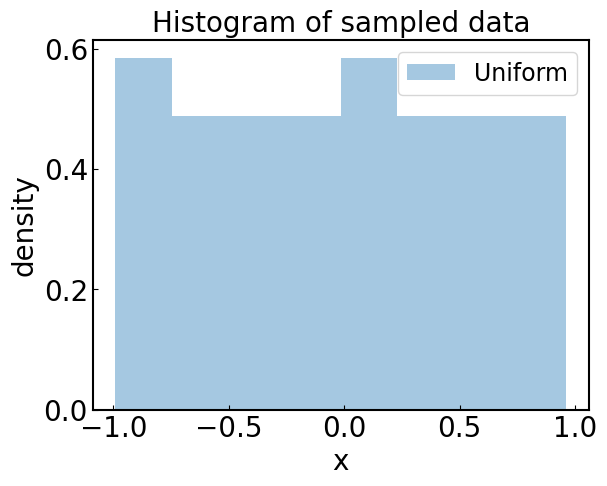

In [6]:
plt.hist(uniform_subsample_states_crn['x4'], bins='auto', density=True, alpha=0.4, label='Uniform')                      

plt.legend()
plt.xlabel('x')
plt.ylabel('density')
plt.title('Histogram of sampled data')
plt.show()

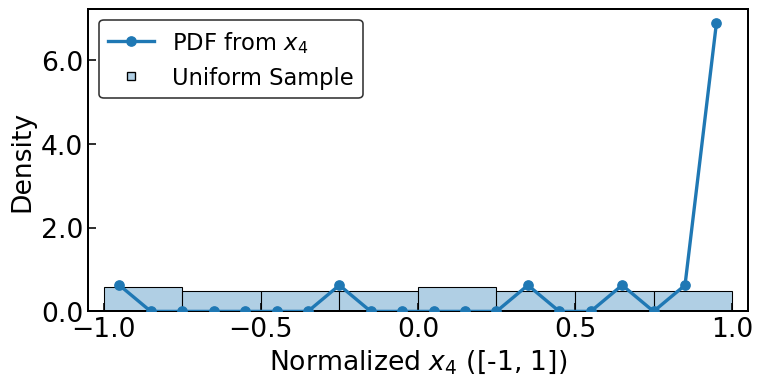

In [ ]:
out_path_plots2 = Path("/Users/yuxiangfeng/Desktop/SINDy/Plots/Fig2_modify")
font_size = 20
dpi = 96
# color & marker
color_map = {
    'x4': '#1F78B4',  
}
marker_map = {
    'x4': 'o',
}
hist_face_color = mcolors.to_rgba(color_map['x4'], alpha=0.35)

x_raw  = uniform_subsample_states_crn['x4'].to_numpy()  # Histogram data
x_data = data_states['x4'].to_numpy()                   # PDF curve for all data

# Normalize to [-1, 1]
L_raw,  U_raw  = x_raw.min(),  x_raw.max()
L_data, U_data = x_data.min(), x_data.max()

x_norm_hist  = 2 * (x_raw  - L_raw)  / (U_raw  - L_raw) - 1
x_norm_data  = 2 * (x_data - L_data) / (U_data - L_data) - 1

# PDF（data_states）
n_bins = 20
density, edges = np.histogram(x_norm_data, bins=n_bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])


fig, ax = plt.subplots(figsize=(8.2677, 4.3307), dpi=dpi)

# Histogram
counts, bins, patches = ax.hist(
    x_norm_hist,
    bins='auto',
    density=True,
    color=hist_face_color,
    edgecolor='black',
    linewidth=0.8
)

# PDF curve (line + points)
ax.plot(
    centers, density,
    color=color_map['x4'],
    linewidth=2.5,
    zorder=3,
)
ax.plot(
    centers, density,
    linestyle='None',
    marker=marker_map['x4'],
    markersize=7,
    markerfacecolor=color_map['x4'],
    markeredgecolor=color_map['x4'],
    zorder=4,
)

ax.set_xlabel(r'Normalized $x_4$ ([-1, 1])', fontsize=font_size)
ax.set_ylabel('Density', fontsize=font_size)
ax.set_xlim(-1.05, 1.05)

ymax = max(density.max(), counts.max())
ax.set_ylim(0, 1.05 * ymax)

ax.tick_params(axis='both', which='major', length=6, width=1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


# Legend
handle_curve = Line2D(
    [0], [0],
    color=color_map['x4'],
    marker=marker_map['x4'],
    markersize=7,
    linewidth=2.5,
    markerfacecolor=color_map['x4'],
    markeredgecolor=color_map['x4'],
    label=r'PDF from $x_4$'
)

handle_hist = Line2D(
    [0], [0],
    color=hist_face_color,
    marker='s',
    markersize=6,
    linestyle='None',
    markerfacecolor=hist_face_color,
    markeredgecolor='black',
    label='Uniform Sample'
)

leg = ax.legend(
    handles=[handle_curve, handle_hist],
    loc='upper left',
    frameon=True,
    edgecolor='black'
)
leg.get_frame().set_linewidth(1.2)

plt.tight_layout()
fig.savefig(out_path_plots2 / "Uniform_CRN.png", dpi=96,
            bbox_inches="tight", pad_inches=0.02)
plt.show()

'#A6CEE3', '#1F78B4','#B2DF8A', '#33A02C','#FDBF6F', '#FF7F00'  

color_map ={
    'x1': '#f28e2b',  # orange
    'x2': '#4e79a7',  # blue-teal
    'x3': '#b07aa1',  # purple
    'x4': '#59a14f',  # green
}

Exponential Dsitribution

In [8]:
# exponential distribution
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/CRN")
out_path = dir / "IC_exponential"
#out_path = dir / "IC_uniform"
k_rates = {"k":2.12456, "kr":1.10124, "kcat":1.5093}
num = 750

start = 0
end = 0.01
n_step = 5 # actually n-1 steps

#Sample = sampling(data,num,distribution='uniform',noise_level=None)
Sample = sampling(data,num,distribution='exponential')
L, U  = Sample.L_orig, Sample.U_orig
filepaths = Sample.fit_and_save_base(model_name = 'CRN',
    out_path = out_path,
    start = start,
    end = end,
    n_step = n_step,
    k_rates = k_rates,
    method = 'Laguerre',
    noise_level = None
)

exp_sample_crn = Sample._subsample(filepaths,L,U)

exp_sample_crn['time'] = range(1, len(exp_sample_crn) + 1)
exp_data_time_states_crn = exp_sample_crn[states_with_time_cols_crn]
exp_subsample_states_crn = exp_sample_crn[state_cols_crn] 
exp_subsample_derivatives_crn = exp_sample_crn[derivative_cols_crn]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'x4', 'dx1/dt', 'dx2/dt', 'dx3/dt', 'dx4/dt']


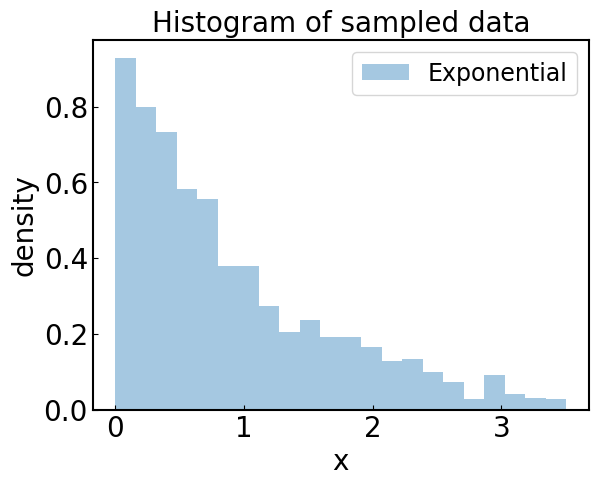

In [9]:
plt.hist(exp_subsample_states_crn['x4'], bins='auto', density=True, alpha=0.4, label='Exponential')                      

plt.legend()
plt.xlabel('x')
plt.ylabel('density')
plt.title('Histogram of sampled data')
plt.show()

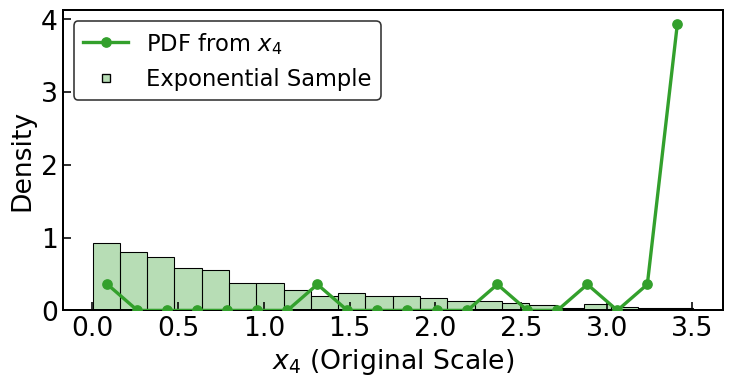

In [ ]:
# color & marker
color_map = {
    'x4': '#33A02C',  
}
marker_map = {
    'x4': 'o',
}
hist_face_color = mcolors.to_rgba(color_map['x4'], alpha=0.35)
 
x_raw  = exp_subsample_states_crn['x4'].to_numpy()  # Histogram data
x_data = data_states['x4'].to_numpy()               # PDF curve for all data

# PDF（data_states)
n_bins = 20
density, edges = np.histogram(x_data, bins=n_bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(7.9409, 4.3307), dpi=dpi)

# Histogram 
counts, bins, patches = ax.hist(
    x_raw,
    bins='auto',
    density=True,
    color=hist_face_color,
    edgecolor='black',
    linewidth=0.8
)

# PDF curve (line + points)
ax.plot(
    centers, density,
    color=color_map['x4'],
    linewidth=2.5,
    zorder=3,
)
ax.plot(
    centers, density,
    linestyle='None',
    marker=marker_map['x4'],
    markersize=7,
    markerfacecolor=color_map['x4'],
    markeredgecolor=color_map['x4'],
    zorder=4,
)

ax.set_xlabel(r'$x_4$ (Original Scale)', fontsize=font_size)
ax.set_ylabel('Density', fontsize=font_size)
margin = 0.05 * (x_raw.max() - x_raw.min())
#ax_hist.set_xlim(x_raw.min() - margin, x_raw.max() + margin)

ymax = max(density.max(), counts.max())
ax.set_ylim(0, 1.05 * ymax)
ax.tick_params(axis='both', which='major', length=6, width=1.2)

# Legend
handle_curve = Line2D(
    [0], [0],
    color=color_map['x4'],
    marker=marker_map['x4'],
    markersize=7,
    linewidth=2.5,
    markerfacecolor=color_map['x4'],
    markeredgecolor=color_map['x4'],
    label=r'PDF from $x_4$'
)

handle_hist = Line2D(
    [0], [0],
    color=hist_face_color,
    marker='s',
    markersize=6,
    linestyle='None',
    markerfacecolor=hist_face_color,
    markeredgecolor='black',
    label='Exponential Sample'
)

leg = ax.legend(
    handles=[handle_curve, handle_hist],
    loc='upper left',
    frameon=True,
    edgecolor='black'
)
leg.get_frame().set_linewidth(1.2)

plt.tight_layout()
fig.savefig(out_path_plots2 / "Exp_CRN.png", dpi=96,
            bbox_inches="tight", pad_inches=0.02)
plt.show()

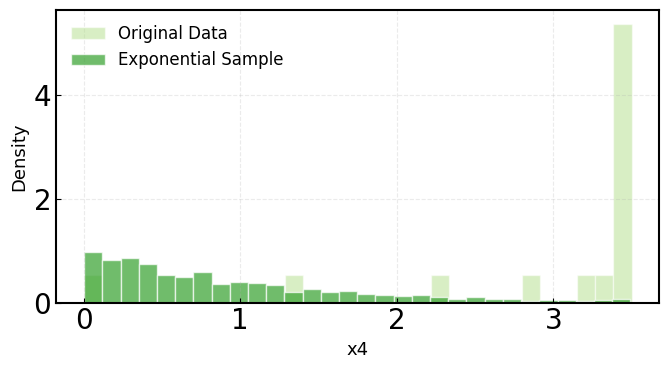

In [142]:
# Use light green and dark green color pair
plt.figure(figsize=(7, 4))
plt.hist(data_states['x4'], bins=30, density=True, alpha=0.5, color='#B2DF8A', edgecolor='white', label='Original Data')  # light green
plt.hist(exp_subsample_states_crn['x4'], bins=30, density=True, alpha=0.7, color='#33A02C', edgecolor='white', label='Exponential Sample')  # dark green
plt.xlabel('x4', fontsize=13)
plt.ylabel('Density', fontsize=13)
#plt.title('Histogram of x4
# Original vs Exponential Sample', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, frameon=False)
plt.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

Arcsine Distribution

In [11]:
# arcsine distribution
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/CRN")
out_path = dir / "IC_arcsine"
#out_path = dir / "IC_uniform"
k_rates = {"k":2.12456, "kr":1.10124, "kcat":1.5093}
num = 50

start = 0
end = 0.01
n_step = 5 # actually n-1 steps

#Sample = sampling(data,num,distribution='uniform',noise_level=None)
Sample = sampling(data,num,distribution='arcsine')
L, U  = Sample.L_orig, Sample.U_orig
filepaths = Sample.fit_and_save_base(model_name = 'CRN',
    out_path = out_path,
    start = start,
    end = end,
    n_step = n_step,
    k_rates = k_rates,
    method = 'Chebyshev',
    noise_level = None
)

arcsine_sample_crn = Sample._subsample(filepaths,L,U)

arcsine_sample_crn['time'] = range(1, len(arcsine_sample_crn) + 1)
arcsine_data_time_states_crn = arcsine_sample_crn[states_with_time_cols_crn]
arcsine_subsample_states_crn = arcsine_sample_crn[state_cols_crn] 
arcsine_subsample_derivatives_crn = arcsine_sample_crn[derivative_cols_crn]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'x4', 'dx1/dt', 'dx2/dt', 'dx3/dt', 'dx4/dt']


/Users/yuxiangfeng/Desktop/SINDy/3.Dependence/illposed_env/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning:

invalid value encountered in log



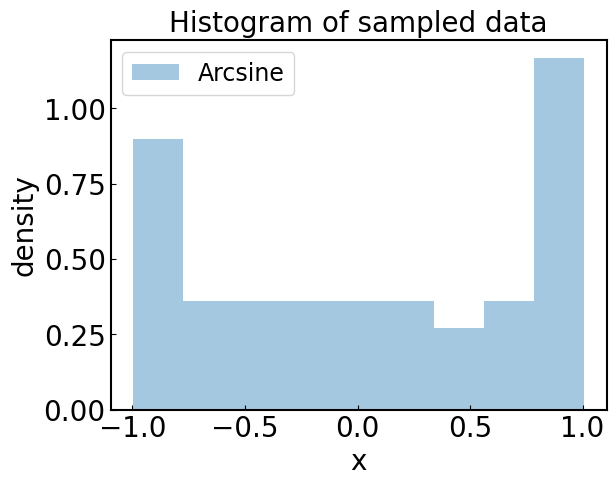

In [12]:
plt.hist(arcsine_subsample_states_crn['x4'], bins='auto', density=True, alpha=0.4, label='Arcsine')                      

plt.legend()
plt.xlabel('x')
plt.ylabel('density')
plt.title('Histogram of sampled data')
plt.show()

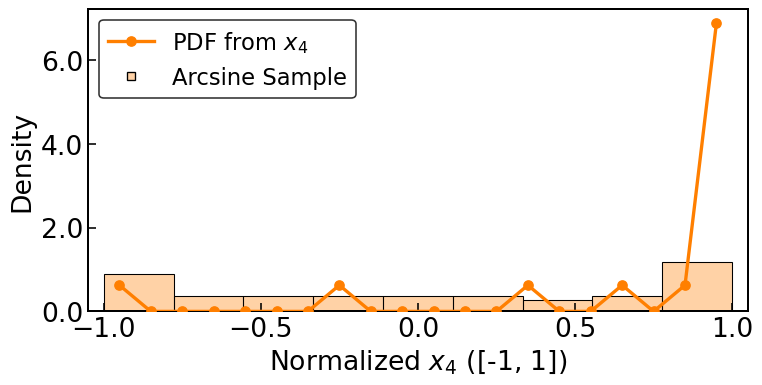

In [ ]:
# color & marker
color_map = {
    'x4': '#FF7F00',  
}
marker_map = {
    'x4': 'o',
}
hist_face_color = mcolors.to_rgba(color_map['x4'], alpha=0.35)

x_raw  = arcsine_subsample_states_crn['x4'].to_numpy()  # Histogram data
x_data = data_states['x4'].to_numpy()               # PDF curve for all data

# Normalize to [-1, 1]
L_raw,  U_raw  = x_raw.min(),  x_raw.max()
L_data, U_data = x_data.min(), x_data.max()

x_norm_hist  = 2 * (x_raw  - L_raw)  / (U_raw  - L_raw) - 1
x_norm_data  = 2 * (x_data - L_data) / (U_data - L_data) - 1

# PDF（data_states）
n_bins = 20
density, edges = np.histogram(x_norm_data, bins=n_bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(8.2677, 4.3307), dpi=dpi)

# Histogram
counts, bins, patches = ax.hist(
    x_norm_hist,
    bins='auto',
    density=True,
    color=hist_face_color,
    edgecolor='black',
    linewidth=0.8
)

# PDF curve (line + points)
ax.plot(
    centers, density,
    color=color_map['x4'],
    linewidth=2.5,
    zorder=3,
)
ax.plot(
    centers, density,
    linestyle='None',
    marker=marker_map['x4'],
    markersize=7,
    markerfacecolor=color_map['x4'],
    markeredgecolor=color_map['x4'],
    zorder=4,
)

ax.set_xlabel(r'Normalized $x_4$ ([-1, 1])', fontsize=font_size)
ax.set_ylabel('Density', fontsize=font_size)
ax.set_xlim(-1.05, 1.05)

ymax = max(density.max(), counts.max())
ax.set_ylim(0, 1.05 * ymax)

ax.tick_params(axis='both', which='major', length=6, width=1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# Legend
handle_curve = Line2D(
    [0], [0],
    color=color_map['x4'],
    marker=marker_map['x4'],
    markersize=7,
    linewidth=2.5,
    markerfacecolor=color_map['x4'],
    markeredgecolor=color_map['x4'],
    label=r'PDF from $x_4$'
)

handle_hist = Line2D(
    [0], [0],
    color=hist_face_color,
    marker='s',
    markersize=6,
    linestyle='None',
    markerfacecolor=hist_face_color,
    markeredgecolor='black',
    label='Arcsine Sample'
)

leg = ax.legend(
    handles=[handle_curve, handle_hist],
    loc='upper left',
    frameon=True,
    edgecolor='black'
)
leg.get_frame().set_linewidth(1.2)

plt.tight_layout()
fig.savefig(out_path_plots2 / "Arcsine_CRN.png", dpi=96,
            bbox_inches="tight", pad_inches=0.02)
plt.show()

Lotka-Volterra

In [15]:
# 1 prey, 2 predators Lotka-Volterra model
dir_lv = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/Lotka-Volterra")
LV_model = pd.read_excel(dir_lv / 'Model_LV_1_2.xlsx')
params = {"r":0.2, "K":1.7, "a1":0.1, "a2":0.2, "m1":0.1, "m2":0.1, "epsilon1":1.0, "epsilon2":2.0}
t_span = (0,20)
t_eval = np.linspace(t_span[0],t_span[1],21)

#z0 = [10,10]
z0 = [1.7,1.0,1.7]
noise_level = 0.1
LV = Lotka_Volterra(params,t_span,t_eval,z0,noise_level=None)

data_overall_lv = LV.data_sim
data_overall_lv.rename(columns={"x":"x1", "y1":"x2", "y2":"x3", "dxdt":"dx1dt", "dy1dt":"dx2dt", "dy2dt":"dx3dt"},inplace=True)
data_lv = data_overall_lv[['time','x1','x2','x3']]
#data_dot_lv = data_overall_lv[['dx1dt','dx2dt','dx3dt']]
data_states_lv = data_overall_lv[['x1','x2','x3']]
state_cols_lv = [col for col in data_states_lv.columns if col != 'time' and '/dt' and 'dt' not in col]

min_lv = data_states_lv.min()
max_lv = data_states_lv.max()


# normalize for orthogonal basis
time_column = data_lv['time']
data_states_lv_normalized = normalization(data_states_lv)[0]
data_lv_normalized = pd.concat([time_column, data_states_lv_normalized], axis=1)

Uniform Distribution

In [16]:
# uniform distribution normalized
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/Lotka-Volterra")
out_path = dir / "IC_uniform"
num = 100

start = 0
end = 0.05
n_step = 5 # actually n-1 steps

Sample = sampling(data_lv,num,distribution='uniform',noise_level=None)
#Sample = sampling(data,num,distribution='exponential')
L, U  = min_lv, max_lv
filepaths = Sample.fit_and_save_base(model_name = 'Lotka-Volterra',
    out_path = out_path,
    start = start,
    end = end,
    n_step = n_step,
    params = params,
    method = 'Legendre',
    noise_level = None
)

uniform_sample_lv = Sample._subsample(filepaths,L,U)

state_cols_lv = [col for col in uniform_sample_lv.columns if col != 'time' and '/dt' and 'dt' not in col]
time_col = 'time'
states_with_time_cols_lv = [time_col] + state_cols_lv
derivative_cols_lv = [f'd{col}/dt' for col in state_cols_lv]

uniform_sample_lv['time'] = range(1, len(uniform_sample_lv) + 1)
uniform_data_time_states_lv = uniform_sample_lv[states_with_time_cols_lv]
uniform_subsample_states_lv = uniform_sample_lv[state_cols_lv] 
uniform_subsample_derivatives_lv = uniform_sample_lv[derivative_cols_lv]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'dx1/dt', 'dx2/dt', 'dx3/dt']


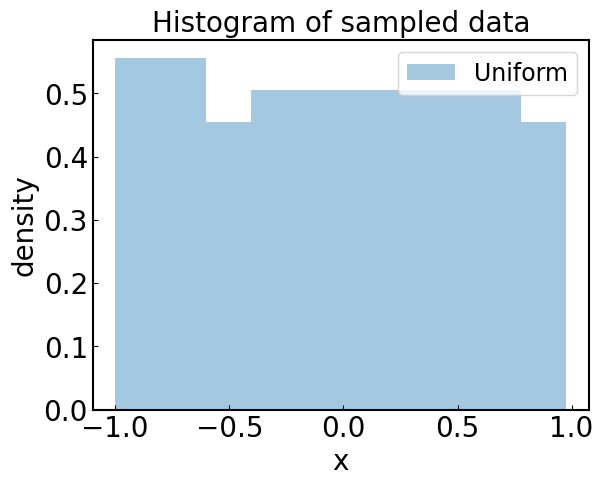

In [17]:
plt.hist(uniform_subsample_states_lv['x2'], bins='auto', density=True, alpha=0.4, label='Uniform')                      

plt.legend()
plt.xlabel('x')
plt.ylabel('density')
plt.title('Histogram of sampled data')
plt.show()

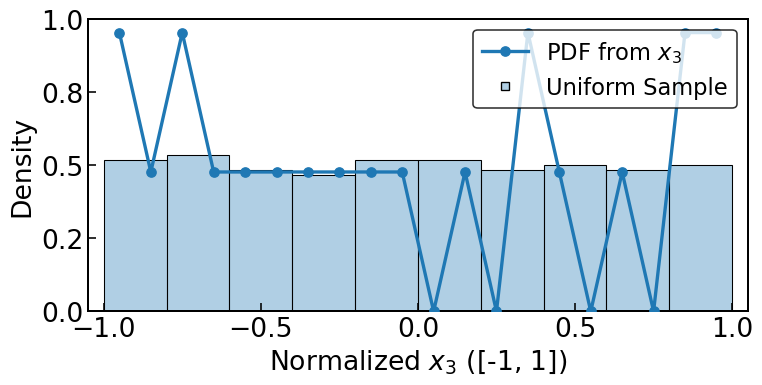

In [ ]:
# color & marker
color_map = {
    'x3': '#1F78B4',  
}
marker_map = {
    'x3': 'o',
}
hist_face_color = mcolors.to_rgba(color_map['x3'], alpha=0.35)

x_raw  = uniform_subsample_states_lv['x3'].to_numpy()  # Histogram data
x_data = data_states_lv['x3'].to_numpy()               # PDF curve for all data

# Normalize to [-1, 1]
L_raw,  U_raw  = x_raw.min(),  x_raw.max()
L_data, U_data = x_data.min(), x_data.max()

x_norm_hist  = 2 * (x_raw  - L_raw)  / (U_raw  - L_raw) - 1
x_norm_data  = 2 * (x_data - L_data) / (U_data - L_data) - 1

# PDF（data_states）
n_bins = 20
density, edges = np.histogram(x_norm_data, bins=n_bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(8.2677, 4.3307), dpi=dpi)

# Histogram
counts, bins, patches = ax.hist(
    x_norm_hist,
    bins='auto',
    density=True,
    color=hist_face_color,
    edgecolor='black',
    linewidth=0.8
)

# PDF curve (line + points)
ax.plot(
    centers, density,
    color=color_map['x3'],
    linewidth=2.5,
    zorder=3,
)
ax.plot(
    centers, density,
    linestyle='None',
    marker=marker_map['x3'],
    markersize=7,
    markerfacecolor=color_map['x3'],
    markeredgecolor=color_map['x3'],
    zorder=4,
)

ax.set_xlabel(r'Normalized $x_3$ ([-1, 1])', fontsize=font_size)
ax.set_ylabel('Density', fontsize=font_size)
ax.set_xlim(-1.05, 1.05)

ymax = max(density.max(), counts.max())
ax.set_ylim(0, 1.05 * ymax)

ax.tick_params(axis='both', which='major', length=6, width=1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# Legend
handle_curve = Line2D(
    [0], [0],
    color=color_map['x3'],
    marker=marker_map['x3'],
    markersize=7,
    linewidth=2.5,
    markerfacecolor=color_map['x3'],
    markeredgecolor=color_map['x3'],
    label=r'PDF from $x_3$'
)

handle_hist = Line2D(
    [0], [0],
    color=hist_face_color,
    marker='s',
    markersize=6,
    linestyle='None',
    markerfacecolor=hist_face_color,
    markeredgecolor='black',
    label='Uniform Sample'
)

leg = ax.legend(
    handles=[handle_curve, handle_hist],
    loc='upper right',
    frameon=True,
    edgecolor='black'
)
leg.get_frame().set_linewidth(1.2)

plt.tight_layout()
fig.savefig(out_path_plots2 / "Uniform_LV.png", dpi=96,
            bbox_inches="tight", pad_inches=0.02)
plt.show()

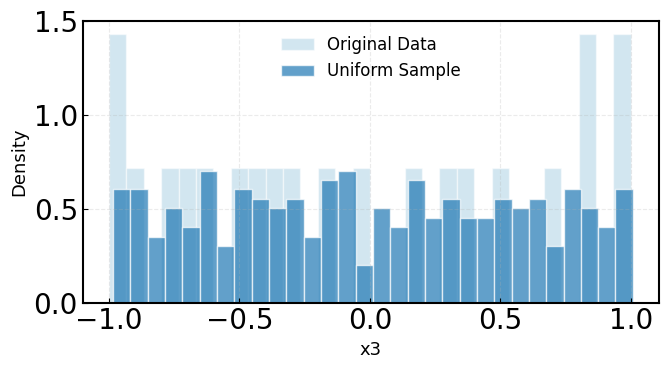

In [152]:
# Improve plot aesthetics
plt.figure(figsize=(7, 4))
plt.hist(data_states_lv_normalized['x3'], bins=30, density=True, alpha=0.5, color='#A6CEE3', edgecolor='white', label='Original Data')
plt.hist(uniform_subsample_states_lv['x3'], bins=30, density=True, alpha=0.7, color='#1F78B4', edgecolor='white', label='Uniform Sample')
plt.xlabel('x3', fontsize=13)
plt.ylabel('Density', fontsize=13)
#plt.title('Histogram of x4: Original vs Uniform Sample', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, frameon=False)
plt.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

Exponential Distribution

In [19]:
# exponential distribution
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/Lotka-Volterra")
out_path = dir / "IC_exponential"
num = 500

start = 0
end = 0.01
n_step = 10 # actually n-1 steps

#Sample = sampling(data,num,distribution='uniform',noise_level=None)
Sample = sampling(data_lv,num,distribution='exponential')
L, U  = min_lv, max_lv
filepaths = Sample.fit_and_save_base(model_name = 'Lotka-Volterra',
    out_path = out_path,
    start = start,
    end = end,
    n_step = n_step,
    params = params,
    method = 'Laguerre',
    noise_level = None
)

exp_sample_lv = Sample._subsample(filepaths,L,U)

exp_sample_lv['time'] = range(1, len(exp_sample_lv) + 1)
exp_data_time_states_lv = exp_sample_lv[states_with_time_cols_lv]
exp_subsample_states_lv = exp_sample_lv[state_cols_lv] 
exp_subsample_derivatives_lv = exp_sample_lv[derivative_cols_lv]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'dx1/dt', 'dx2/dt', 'dx3/dt']


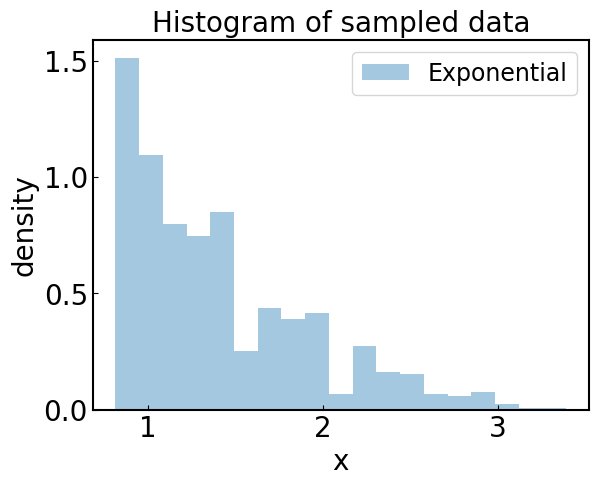

In [20]:
plt.hist(exp_subsample_states_lv['x3'], bins='auto', density=True, alpha=0.4, label='Exponential')                      

plt.legend()
plt.xlabel('x')
plt.ylabel('density')
plt.title('Histogram of sampled data')
plt.show()

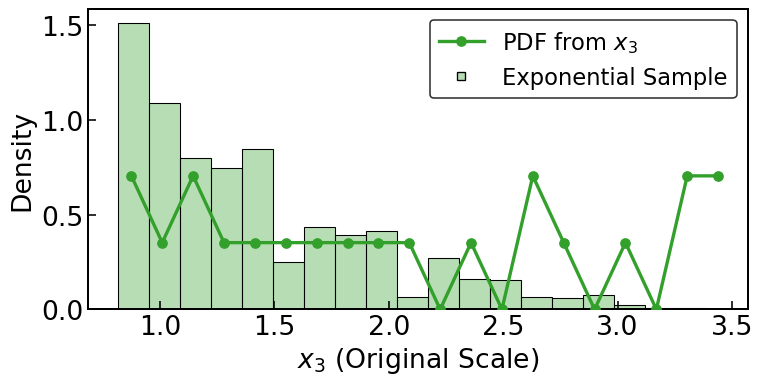

In [ ]:
# color & marker
color_map = {
    'x3': '#33A02C',  
}
marker_map = {
    'x3': 'o',
}
hist_face_color = mcolors.to_rgba(color_map['x3'], alpha=0.35)

x_raw  = exp_subsample_states_lv['x3'].to_numpy()      # Histogram data
x_data = data_states_lv['x3'].to_numpy()               # PDF curve for all data

# PDF（data_states）
n_bins = 20
density, edges = np.histogram(x_data, bins=n_bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(8.2677, 4.3307), dpi=dpi)

# Histogram
counts, bins, patches = ax.hist(
    x_raw,
    bins='auto',
    density=True,
    color=hist_face_color,
    edgecolor='black',
    linewidth=0.8
)

# PDF curve (line + points)
ax.plot(
    centers, density,
    linestyle='-', linewidth = 2.5,
    color=color_map['x3'],
    marker=marker_map['x3'],
    markersize=7,
    markerfacecolor=color_map['x3'],
    markeredgecolor=color_map['x3'],
    zorder=4,
)

ax.set_xlabel(r'$x_3$ (Original Scale)', fontsize=font_size)
ax.set_ylabel('Density', fontsize=font_size)
margin = 0.05 * (x_raw.max() - x_raw.min())
#ax_hist.set_xlim(x_raw.min() - margin, x_raw.max() + margin)

ymax = max(density.max(), counts.max())
ax.set_ylim(0, 1.05 * ymax)
ax.tick_params(axis='both', which='major', length=6, width=1.2)

# Legend
handle_curve = Line2D(
    [0], [0],
    color=color_map['x3'],
    marker=marker_map['x3'],
    markersize=7,
    linewidth=2.5,
    markerfacecolor=color_map['x3'],
    markeredgecolor=color_map['x3'],
    label=r'PDF from $x_3$'
)

handle_hist = Line2D(
    [0], [0],
    color=hist_face_color,
    marker='s',
    markersize=6,
    linestyle='None',
    markerfacecolor=hist_face_color,
    markeredgecolor='black',
    label='Exponential Sample'
)

leg = ax.legend(
    handles=[handle_curve, handle_hist],
    loc='upper right',
    frameon=True,
    edgecolor='black'
)
leg.get_frame().set_linewidth(1.2)

plt.tight_layout()
fig.savefig(out_path_plots2 / "Exp_LV.png", dpi=96,
            bbox_inches="tight", pad_inches=0.02)
plt.show()

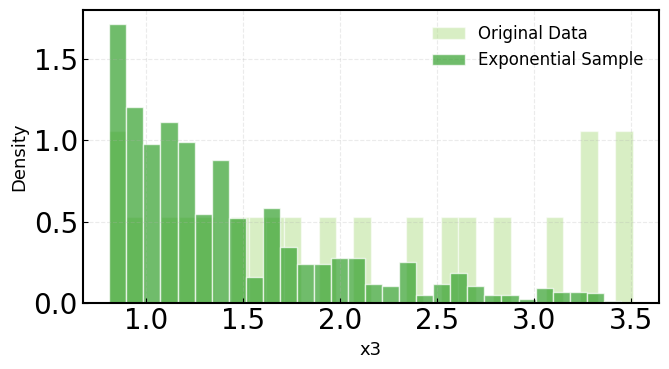

In [157]:
# Use light green and dark green color pair
plt.figure(figsize=(7, 4))
plt.hist(data_states_lv['x3'], bins=30, density=True, alpha=0.5, color='#B2DF8A', edgecolor='white', label='Original Data')  # light green
plt.hist(exp_subsample_states_lv['x3'], bins=30, density=True, alpha=0.7, color='#33A02C', edgecolor='white', label='Exponential Sample')  # dark green
plt.xlabel('x3', fontsize=13)
plt.ylabel('Density', fontsize=13)
#plt.title('Histogram of x3: Original vs Exponential Sample', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, frameon=False)
plt.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

Arcsine Distribution

In [22]:
# arcsine distribution
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/Lotka-Volterra")
out_path = dir / "IC_arcsine"
num = 100

start = 0
end = 0.05
n_step = 5 # actually n-1 steps

Sample = sampling(data_lv,num,distribution='arcsine', noise_level=None)
L, U  = min_lv, max_lv
filepaths = Sample.fit_and_save_base(model_name = 'Lotka-Volterra',
    out_path = out_path,
    start = start,
    end = end,
    n_step = n_step,
    params = params,
    method = 'Chebyshev',
    noise_level = None
)

arcsine_sample_lv = Sample._subsample(filepaths,L,U)

arcsine_sample_lv['time'] = range(1, len(arcsine_sample_lv) + 1)
arcsine_data_time_states_lv = arcsine_sample_lv[states_with_time_cols_lv]
arcsine_subsample_states_lv = arcsine_sample_lv[state_cols_lv] 
arcsine_subsample_derivatives_lv = arcsine_sample_lv[derivative_cols_lv]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'dx1/dt', 'dx2/dt', 'dx3/dt']


/Users/yuxiangfeng/Desktop/SINDy/3.Dependence/illposed_env/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning:

invalid value encountered in log



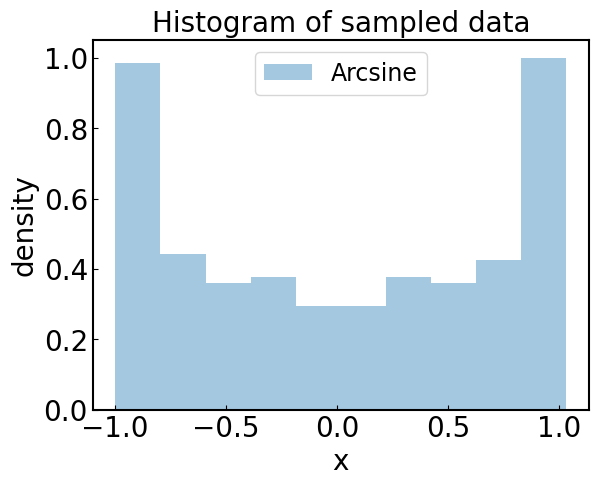

In [23]:
plt.hist(arcsine_subsample_states_lv['x3'], bins='auto', density=True, alpha=0.4, label='Arcsine')                      

plt.legend()
plt.xlabel('x')
plt.ylabel('density')
plt.title('Histogram of sampled data')
plt.show()

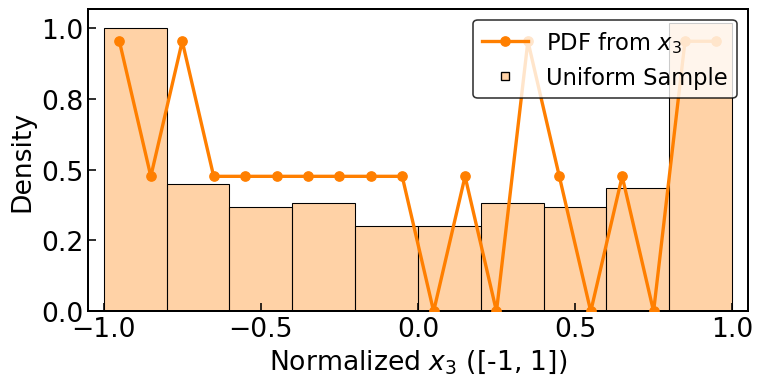

In [ ]:
# color & marker
color_map = {
    'x3': '#FF7F00',  
}
marker_map = {
    'x3': 'o',
}
hist_face_color = mcolors.to_rgba(color_map['x3'], alpha=0.35)

x_raw  = arcsine_subsample_states_lv['x3'].to_numpy()  # Histogram data
x_data = data_states_lv['x3'].to_numpy()               # PDF curve for all data

# Normalize to [-1, 1]
L_raw,  U_raw  = x_raw.min(),  x_raw.max()
L_data, U_data = x_data.min(), x_data.max()

x_norm_hist  = 2 * (x_raw  - L_raw)  / (U_raw  - L_raw) - 1
x_norm_data  = 2 * (x_data - L_data) / (U_data - L_data) - 1

# PDF（data_states）
n_bins = 20
density, edges = np.histogram(x_norm_data, bins=n_bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, ax = plt.subplots(figsize=(8.2677, 4.3307), dpi=dpi)

# Histogram
counts, bins, patches = ax.hist(
    x_norm_hist,
    bins='auto',
    density=True,
    color=hist_face_color,
    edgecolor='black',
    linewidth=0.8
)

# PDF curve (line + points)
ax.plot(
    centers, density,
    color=color_map['x3'],
    linewidth=2.5,
    zorder=3,
)
ax.plot(
    centers, density,
    linestyle='None',
    marker=marker_map['x3'],
    markersize=7,
    markerfacecolor=color_map['x3'],
    markeredgecolor=color_map['x3'],
    zorder=4,
)

ax.set_xlabel(r'Normalized $x_3$ ([-1, 1])', fontsize=font_size)
ax.set_ylabel('Density', fontsize=font_size)
ax.set_xlim(-1.05, 1.05)

ymax = max(density.max(), counts.max())
ax.set_ylim(0, 1.05 * ymax)

ax.tick_params(axis='both', which='major', length=6, width=1.2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# Legend
handle_curve = Line2D(
    [0], [0],
    color=color_map['x3'],
    marker=marker_map['x3'],
    markersize=7,
    linewidth=2.5,
    markerfacecolor=color_map['x3'],
    markeredgecolor=color_map['x3'],
    label=r'PDF from $x_3$'
)

handle_hist = Line2D(
    [0], [0],
    color=hist_face_color,
    marker='s',
    markersize=6,
    linestyle='None',
    markerfacecolor=hist_face_color,
    markeredgecolor='black',
    label='Uniform Sample'
)

leg = ax.legend(
    handles=[handle_curve, handle_hist],
    loc='upper right',
    frameon=True,
    edgecolor='black'
)
leg.get_frame().set_linewidth(1.2)

plt.tight_layout()
fig.savefig(out_path_plots2 / "Arcsine_LV.png", dpi=96,
            bbox_inches="tight", pad_inches=0.02)
plt.show()

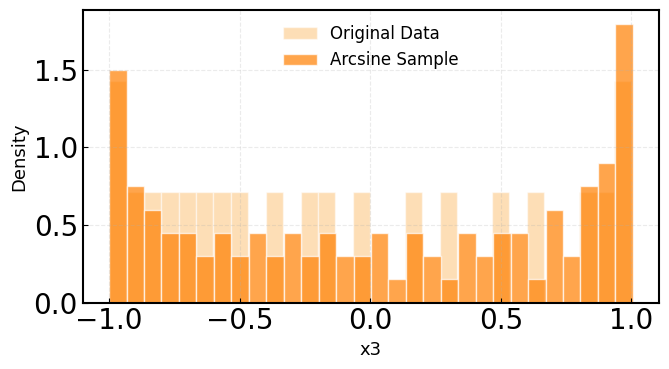

In [162]:
# Use light orange and dark orange color pair
plt.figure(figsize=(7, 4))
plt.hist(data_states_lv_normalized['x2'], bins=30, density=True, alpha=0.5, color='#FDBF6F', edgecolor='white', label='Original Data')  # light orange
plt.hist(arcsine_subsample_states_lv['x2'], bins=30, density=True, alpha=0.7, color='#FF7F00', edgecolor='white', label='Arcsine Sample')  # dark orange
plt.xlabel('x3', fontsize=13)
plt.ylabel('Density', fontsize=13)
#plt.title('Histogram of x4: Original vs Arcsine Sample (LV)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, frameon=False)
plt.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

Plot2: Condition Number of basis library

Chemical Reaction Network

Construct Function Library using sampled data

In [28]:
# Monomial basis
Monomial_uniform = Monomials(uniform_data_time_states_crn,degree=5)
Monomial_uniform_lib = Monomial_uniform._generate_library() 
Monomial_exp = Monomials(exp_data_time_states_crn,degree=5)
Monomial_exp_lib = Monomial_exp._generate_library() 
Monomial_arcsine = Monomials(arcsine_data_time_states_crn,degree=5)
Monomial_arcsine_lib = Monomial_arcsine._generate_library() 

# Legendre basis
Legendre_uniform = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)
Legendre_exp = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)
Legendre_arcsine = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)
Legendre_uniform.fit(uniform_subsample_states_crn)
Legendre_exp.fit(exp_subsample_states_crn)
Legendre_arcsine.fit(arcsine_subsample_states_crn)
Legendre_uniform_lib = Legendre_uniform.transform_to_dataframe(uniform_subsample_states_crn,state_cols_crn)
Legendre_exp_lib = Legendre_exp.transform_to_dataframe(exp_subsample_states_crn,state_cols_crn)
Legendre_arcsine_lib = Legendre_arcsine.transform_to_dataframe(arcsine_subsample_states_crn,state_cols_crn)

# Chebyshev basis
Chebyshev_uniform = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)
Chebyshev_exp = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)
Chebyshev_arcsine = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)
Chebyshev_uniform.fit(uniform_subsample_states_crn)
Chebyshev_exp.fit(exp_subsample_states_crn)
Chebyshev_arcsine.fit(arcsine_subsample_states_crn)
Chebyshev_uniform_lib = Chebyshev_uniform.transform_to_dataframe(uniform_subsample_states_crn,state_cols_crn)
Chebyshev_exp_lib = Chebyshev_exp.transform_to_dataframe(exp_subsample_states_crn,state_cols_crn)
Chebyshev_arcsine_lib = Chebyshev_arcsine.transform_to_dataframe(arcsine_subsample_states_crn,state_cols_crn)

# Laguerre basis
Laguerre_uniform = OrthogonalLibrary(degree=5, method='Laguerre',include_bias=False)
Laguerre_exp = OrthogonalLibrary(degree=5, method='Laguerre',include_bias=False)
Laguerre_arcsine = OrthogonalLibrary(degree=5, method='Laguerre',include_bias=False)
Laguerre_uniform.fit(uniform_subsample_states_crn)
Laguerre_exp.fit(exp_subsample_states_crn)
Laguerre_arcsine.fit(arcsine_subsample_states_crn)
Laguerre_uniform_lib = Laguerre_uniform.transform_to_dataframe(uniform_subsample_states_crn,state_cols_crn)
Laguerre_exp_lib = Laguerre_exp.transform_to_dataframe(exp_subsample_states_crn,state_cols_crn)
Laguerre_arcsine_lib = Laguerre_arcsine.transform_to_dataframe(arcsine_subsample_states_crn,state_cols_crn)

In [29]:
# uniform distribution
uniform_monomial_cond_crn = np.linalg.cond(Monomial_uniform_lib.to_numpy())
uniform_legendre_cond_crn = np.linalg.cond(Legendre_uniform_lib.to_numpy())
uniform_chebyshev_cond_crn = np.linalg.cond(Chebyshev_uniform_lib.to_numpy())
uniform_laguerre_cond_crn = np.linalg.cond(Laguerre_uniform_lib.to_numpy())

# exponential distribution
exp_monomial_cond_crn = np.linalg.cond(Monomial_exp_lib.to_numpy())
exp_legendre_cond_crn = np.linalg.cond(Legendre_exp_lib.to_numpy())
exp_chebyshev_cond_crn = np.linalg.cond(Chebyshev_exp_lib.to_numpy())
exp_laguerre_cond_crn  = np.linalg.cond(Laguerre_exp_lib.to_numpy())

# arcsine distribution
arcsine_monomial_cond_crn = np.linalg.cond(Monomial_arcsine_lib.to_numpy())
arcsine_legendre_cond_crn = np.linalg.cond(Legendre_arcsine_lib.to_numpy())
arcsine_chebyshev_cond_crn = np.linalg.cond(Chebyshev_arcsine_lib.to_numpy())
arcsine_laguerre_cond_crn = np.linalg.cond(Laguerre_arcsine_lib.to_numpy())

In [30]:
# Uniform distribution
uniform_conds_crn = [
    np.log10(uniform_monomial_cond_crn),
    np.log10(uniform_legendre_cond_crn),
    np.log10(uniform_chebyshev_cond_crn)
]

# Exponential distribution
exp_conds_crn = [
    np.log10(exp_monomial_cond_crn),
    np.log10(exp_legendre_cond_crn),
    np.log10(exp_chebyshev_cond_crn)
]

# Arcsine distribution
arcsine_conds_crn = [
    np.log10(arcsine_monomial_cond_crn),
    np.log10(arcsine_legendre_cond_crn),
    np.log10(arcsine_chebyshev_cond_crn)
]

Construct Function Library using Original Data

In [31]:
# Evolve with degree

# Monomial basis
Monomial_ori_2 = Monomials(data,degree=2)
Monomial_ori_3 = Monomials(data,degree=3)
Monomial_ori_4 = Monomials(data,degree=4)
Monomial_ori_5 = Monomials(data,degree=5)

Monomial_lib_ori_2 = Monomial_ori_2._generate_library() 
Monomial_lib_ori_3 = Monomial_ori_3._generate_library()
Monomial_lib_ori_4 = Monomial_ori_4._generate_library()
Monomial_lib_ori_5 = Monomial_ori_5._generate_library()


# Legendre basis
Legendre_ori_2 = OrthogonalLibrary(degree=2, method='Legendre',include_bias=False)
Legendre_ori_3 = OrthogonalLibrary(degree=3, method='Legendre',include_bias=False)
Legendre_ori_4 = OrthogonalLibrary(degree=4, method='Legendre',include_bias=False)
Legendre_ori_5 = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)

Legendre_ori_2.fit(data_states)
Legendre_ori_3.fit(data_states)
Legendre_ori_4.fit(data_states)
Legendre_ori_5.fit(data_states)

Legendre_lib_ori_2 = Legendre_ori_2.transform_to_dataframe(data_states,state_cols_crn)
Legendre_lib_ori_3 = Legendre_ori_3.transform_to_dataframe(data_states,state_cols_crn)
Legendre_lib_ori_4 = Legendre_ori_4.transform_to_dataframe(data_states,state_cols_crn)
Legendre_lib_ori_5 = Legendre_ori_5.transform_to_dataframe(data_states,state_cols_crn)


# Chebyshev basis
Chebyshev_ori_2 = OrthogonalLibrary(degree=2, method='Chebyshev',include_bias=False)
Chebyshev_ori_3 = OrthogonalLibrary(degree=3, method='Chebyshev',include_bias=False)
Chebyshev_ori_4 = OrthogonalLibrary(degree=4, method='Chebyshev',include_bias=False)
Chebyshev_ori_5 = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)

Chebyshev_ori_2.fit(data_states_normalized)
Chebyshev_ori_3.fit(data_states_normalized)
Chebyshev_ori_4.fit(data_states_normalized)
Chebyshev_ori_5.fit(data_states_normalized)

Chebyshev_lib_ori_2 = Chebyshev_ori_2.transform_to_dataframe(data_states_normalized,state_cols_crn)
Chebyshev_lib_ori_3 = Chebyshev_ori_3.transform_to_dataframe(data_states_normalized,state_cols_crn)
Chebyshev_lib_ori_4 = Chebyshev_ori_4.transform_to_dataframe(data_states_normalized,state_cols_crn)
Chebyshev_lib_ori_5 = Chebyshev_ori_5.transform_to_dataframe(data_states_normalized,state_cols_crn)

In [32]:
# Evolve with degree

# Monomial basis
Monomial_ori_2 = Monomials(data,degree=2)
Monomial_ori_3 = Monomials(data,degree=3)
Monomial_ori_4 = Monomials(data,degree=4)
Monomial_ori_5 = Monomials(data,degree=5)

Monomial_lib_ori_2 = Monomial_ori_2._generate_library() 
Monomial_lib_ori_3 = Monomial_ori_3._generate_library()
Monomial_lib_ori_4 = Monomial_ori_4._generate_library()
Monomial_lib_ori_5 = Monomial_ori_5._generate_library()


# Legendre basis
Legendre_ori_2 = OrthogonalLibrary(degree=2, method='Legendre',include_bias=False)
Legendre_ori_3 = OrthogonalLibrary(degree=3, method='Legendre',include_bias=False)
Legendre_ori_4 = OrthogonalLibrary(degree=4, method='Legendre',include_bias=False)
Legendre_ori_5 = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)

Legendre_ori_2.fit(data_states_normalized)
Legendre_ori_3.fit(data_states_normalized)
Legendre_ori_4.fit(data_states_normalized)
Legendre_ori_5.fit(data_states_normalized)

Legendre_lib_ori_2 = Legendre_ori_2.transform_to_dataframe(data_states,state_cols_crn)
Legendre_lib_ori_3 = Legendre_ori_3.transform_to_dataframe(data_states,state_cols_crn)
Legendre_lib_ori_4 = Legendre_ori_4.transform_to_dataframe(data_states,state_cols_crn)
Legendre_lib_ori_5 = Legendre_ori_5.transform_to_dataframe(data_states,state_cols_crn)


# Chebyshev basis
Chebyshev_ori_2 = OrthogonalLibrary(degree=2, method='Chebyshev',include_bias=False)
Chebyshev_ori_3 = OrthogonalLibrary(degree=3, method='Chebyshev',include_bias=False)
Chebyshev_ori_4 = OrthogonalLibrary(degree=4, method='Chebyshev',include_bias=False)
Chebyshev_ori_5 = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)

Chebyshev_ori_2.fit(data_states_normalized)
Chebyshev_ori_3.fit(data_states_normalized)
Chebyshev_ori_4.fit(data_states_normalized)
Chebyshev_ori_5.fit(data_states_normalized)

Chebyshev_lib_ori_2 = Chebyshev_ori_2.transform_to_dataframe(data_states,state_cols_crn)
Chebyshev_lib_ori_3 = Chebyshev_ori_3.transform_to_dataframe(data_states,state_cols_crn)
Chebyshev_lib_ori_4 = Chebyshev_ori_4.transform_to_dataframe(data_states,state_cols_crn)
Chebyshev_lib_ori_5 = Chebyshev_ori_5.transform_to_dataframe(data_states,state_cols_crn)

In [33]:
# Monomial Basis
monomial_cond_crn_ori_2 = np.linalg.cond(Monomial_lib_ori_2.to_numpy())
monomial_cond_crn_ori_3 = np.linalg.cond(Monomial_lib_ori_3.to_numpy())
monomial_cond_crn_ori_4 = np.linalg.cond(Monomial_lib_ori_4.to_numpy())
monomial_cond_crn_ori_5 = np.linalg.cond(Monomial_lib_ori_5.to_numpy())

# Legendre Basis
legendre_cond_crn_ori_2 = np.linalg.cond(Legendre_lib_ori_2.to_numpy())
legendre_cond_crn_ori_3 = np.linalg.cond(Legendre_lib_ori_3.to_numpy())
legendre_cond_crn_ori_4 = np.linalg.cond(Legendre_lib_ori_4.to_numpy())
legendre_cond_crn_ori_5 = np.linalg.cond(Legendre_lib_ori_5.to_numpy())

# Chebyshev Basis
chebyshev_cond_crn_ori_2 = np.linalg.cond(Chebyshev_lib_ori_2.to_numpy())
chebyshev_cond_crn_ori_3 = np.linalg.cond(Chebyshev_lib_ori_3.to_numpy())
chebyshev_cond_crn_ori_4 = np.linalg.cond(Chebyshev_lib_ori_4.to_numpy())
chebyshev_cond_crn_ori_5 = np.linalg.cond(Chebyshev_lib_ori_5.to_numpy())

In [34]:
# Monomial Basis
Monomial_conds_crn = [
    np.log10(monomial_cond_crn_ori_2),
    np.log10(monomial_cond_crn_ori_3),
    np.log10(monomial_cond_crn_ori_4),
    np.log10(monomial_cond_crn_ori_5)
]

# Legendre Basis
Legendre_conds_crn = [
    np.log10(legendre_cond_crn_ori_2),
    np.log10(legendre_cond_crn_ori_3),
    np.log10(legendre_cond_crn_ori_4),
    np.log10(legendre_cond_crn_ori_5)
]

# Chebyshev Basis
Chebyshev_conds_crn = [
    np.log10(chebyshev_cond_crn_ori_2),
    np.log10(chebyshev_cond_crn_ori_3),
    np.log10(chebyshev_cond_crn_ori_4),
    np.log10(chebyshev_cond_crn_ori_5),
]

Lotka-Volterra

Construct Function Library using sampled data

In [35]:
# Monomial basis
Monomial_uniform = Monomials(uniform_data_time_states_lv,degree=5)
Monomial_uniform_lib = Monomial_uniform._generate_library() 
Monomial_exp = Monomials(exp_data_time_states_lv,degree=5)
Monomial_exp_lib = Monomial_exp._generate_library() 
Monomial_arcsine = Monomials(arcsine_data_time_states_lv,degree=5)
Monomial_arcsine_lib = Monomial_arcsine._generate_library() 

# Legendre basis
Legendre_uniform = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)
Legendre_exp = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)
Legendre_arcsine = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)
Legendre_uniform.fit(uniform_subsample_states_lv)
Legendre_exp.fit(exp_subsample_states_lv)
Legendre_arcsine.fit(arcsine_subsample_states_lv)
Legendre_uniform_lib = Legendre_uniform.transform_to_dataframe(uniform_subsample_states_lv,state_cols_lv)
Legendre_exp_lib = Legendre_exp.transform_to_dataframe(exp_subsample_states_lv,state_cols_lv)
Legendre_arcsine_lib = Legendre_arcsine.transform_to_dataframe(arcsine_subsample_states_lv,state_cols_lv)

# Chebyshev basis
Chebyshev_uniform = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)
Chebyshev_exp = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)
Chebyshev_arcsine = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)
Chebyshev_uniform.fit(uniform_subsample_states_lv)
Chebyshev_exp.fit(exp_subsample_states_lv)
Chebyshev_arcsine.fit(arcsine_subsample_states_lv)
Chebyshev_uniform_lib = Chebyshev_uniform.transform_to_dataframe(uniform_subsample_states_lv,state_cols_lv)
Chebyshev_exp_lib = Chebyshev_exp.transform_to_dataframe(exp_subsample_states_lv,state_cols_lv)
Chebyshev_arcsine_lib = Chebyshev_arcsine.transform_to_dataframe(arcsine_subsample_states_lv,state_cols_lv)

In [36]:
# uniform distribution
uniform_monomial_cond_lv = np.linalg.cond(Monomial_uniform_lib.to_numpy())
uniform_legendre_cond_lv = np.linalg.cond(Legendre_uniform_lib.to_numpy())
uniform_chebyshev_cond_lv = np.linalg.cond(Chebyshev_uniform_lib.to_numpy())
uniform_laguerre_cond_lv = np.linalg.cond(Laguerre_uniform_lib.to_numpy())

# arcsine distribution
arcsine_monomial_cond_lv = np.linalg.cond(Monomial_arcsine_lib.to_numpy())
arcsine_legendre_cond_lv = np.linalg.cond(Legendre_arcsine_lib.to_numpy())
arcsine_chebyshev_cond_lv = np.linalg.cond(Chebyshev_arcsine_lib.to_numpy())
arcsine_laguerre_cond_lv = np.linalg.cond(Laguerre_arcsine_lib.to_numpy())

In [37]:
# Uniform distribution
uniform_conds_lv = [
    np.log10(uniform_monomial_cond_lv),
    np.log10(uniform_legendre_cond_lv),
    np.log10(uniform_chebyshev_cond_lv)
]

# Arcsine distribution
arcsine_conds_lv = [
    np.log10(arcsine_monomial_cond_lv),
    np.log10(arcsine_legendre_cond_lv),
    np.log10(arcsine_chebyshev_cond_lv)
]

Construct Function Library using Original Data

In [38]:
# Evolve with degree

# Monomial basis
Monomial_ori_2 = Monomials(data_lv,degree=2)
Monomial_ori_3 = Monomials(data_lv,degree=3)
Monomial_ori_4 = Monomials(data_lv,degree=4)
Monomial_ori_5 = Monomials(data_lv,degree=5)

Monomial_lib_ori_2 = Monomial_ori_2._generate_library() 
Monomial_lib_ori_3 = Monomial_ori_3._generate_library()
Monomial_lib_ori_4 = Monomial_ori_4._generate_library()
Monomial_lib_ori_5 = Monomial_ori_5._generate_library()


# Legendre basis
Legendre_ori_2 = OrthogonalLibrary(degree=2, method='Legendre',include_bias=False)
Legendre_ori_3 = OrthogonalLibrary(degree=3, method='Legendre',include_bias=False)
Legendre_ori_4 = OrthogonalLibrary(degree=4, method='Legendre',include_bias=False)
Legendre_ori_5 = OrthogonalLibrary(degree=5, method='Legendre',include_bias=False)

Legendre_ori_2.fit(data_states_lv_normalized)
Legendre_ori_3.fit(data_states_lv_normalized)
Legendre_ori_4.fit(data_states_lv_normalized)
Legendre_ori_5.fit(data_states_lv_normalized)

Legendre_lib_ori_2 = Legendre_ori_2.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)
Legendre_lib_ori_3 = Legendre_ori_3.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)
Legendre_lib_ori_4 = Legendre_ori_4.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)
Legendre_lib_ori_5 = Legendre_ori_5.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)


# Chebyshev basis
Chebyshev_ori_2 = OrthogonalLibrary(degree=2, method='Chebyshev',include_bias=False)
Chebyshev_ori_3 = OrthogonalLibrary(degree=3, method='Chebyshev',include_bias=False)
Chebyshev_ori_4 = OrthogonalLibrary(degree=4, method='Chebyshev',include_bias=False)
Chebyshev_ori_5 = OrthogonalLibrary(degree=5, method='Chebyshev',include_bias=False)

Chebyshev_ori_2.fit(data_states_lv_normalized)
Chebyshev_ori_3.fit(data_states_lv_normalized)
Chebyshev_ori_4.fit(data_states_lv_normalized)
Chebyshev_ori_5.fit(data_states_lv_normalized)

Chebyshev_lib_ori_2 = Chebyshev_ori_2.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)
Chebyshev_lib_ori_3 = Chebyshev_ori_3.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)
Chebyshev_lib_ori_4 = Chebyshev_ori_4.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)
Chebyshev_lib_ori_5 = Chebyshev_ori_5.transform_to_dataframe(data_states_lv_normalized,state_cols_lv)

In [39]:
# Monomial Basis
monomial_cond_lv_ori_2 = np.linalg.cond(Monomial_lib_ori_2.to_numpy())
monomial_cond_lv_ori_3 = np.linalg.cond(Monomial_lib_ori_3.to_numpy())
monomial_cond_lv_ori_4 = np.linalg.cond(Monomial_lib_ori_4.to_numpy())
monomial_cond_lv_ori_5 = np.linalg.cond(Monomial_lib_ori_5.to_numpy())

# Legendre Basis
legendre_cond_lv_ori_2 = np.linalg.cond(Legendre_lib_ori_2.to_numpy())
legendre_cond_lv_ori_3 = np.linalg.cond(Legendre_lib_ori_3.to_numpy())
legendre_cond_lv_ori_4 = np.linalg.cond(Legendre_lib_ori_4.to_numpy())
legendre_cond_lv_ori_5 = np.linalg.cond(Legendre_lib_ori_5.to_numpy())

# Chebyshev Basis
chebyshev_cond_lv_ori_2 = np.linalg.cond(Chebyshev_lib_ori_2.to_numpy())
chebyshev_cond_lv_ori_3 = np.linalg.cond(Chebyshev_lib_ori_3.to_numpy())
chebyshev_cond_lv_ori_4 = np.linalg.cond(Chebyshev_lib_ori_4.to_numpy())
chebyshev_cond_lv_ori_5 = np.linalg.cond(Chebyshev_lib_ori_5.to_numpy())

In [40]:
# Monomial Basis
Monomial_conds_lv = [
    np.log10(monomial_cond_lv_ori_2),
    np.log10(monomial_cond_lv_ori_3),
    np.log10(monomial_cond_lv_ori_4),
    np.log10(monomial_cond_lv_ori_5)
]

# Legendre Basis
Legendre_conds_lv = [
    np.log10(legendre_cond_lv_ori_2),
    np.log10(legendre_cond_lv_ori_3),
    np.log10(legendre_cond_lv_ori_4),
    np.log10(legendre_cond_lv_ori_5)
]

# Chebyshev Basis
Chebyshev_conds_lv = [
    np.log10(chebyshev_cond_lv_ori_2),
    np.log10(chebyshev_cond_lv_ori_3),
    np.log10(chebyshev_cond_lv_ori_4),
    np.log10(chebyshev_cond_lv_ori_5)
]

#1F78B4  
#33A02C  
#FF7F00

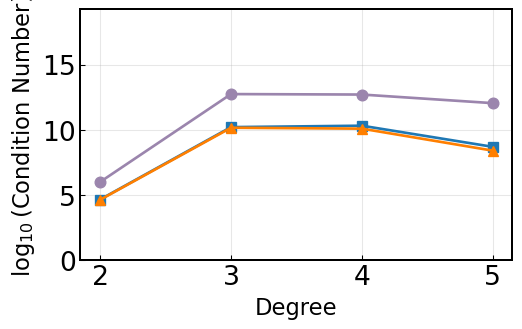

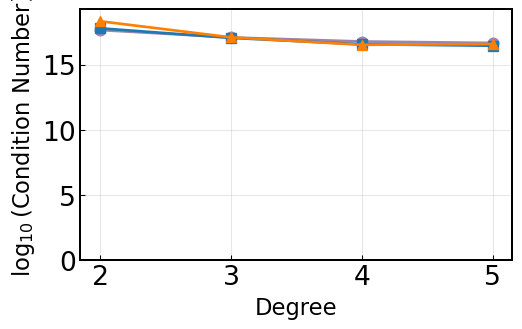

In [ ]:
from matplotlib.ticker import MultipleLocator

out_path_plots1 = Path("/Users/yuxiangfeng/Desktop/SINDy/Plots/Fig1_modify")

# degrees for the libraries
degrees = np.array([2, 3, 4, 5])

lv_ori = {
    'Monomial' : Monomial_conds_lv,
    'Legendre' : Legendre_conds_lv,
    'Chebyshev': Chebyshev_conds_lv,
}
crn_ori = {
    'Monomial' : Monomial_conds_crn,
    'Legendre' : Legendre_conds_crn,
    'Chebyshev': Chebyshev_conds_crn,
}

basis_order  = ['Monomial', 'Legendre', 'Chebyshev']  # only these three

basis_colors = {
    'Legendre' : '#1F78B4',  # Uniform
    'Chebyshev': '#FF7F00',  # Arcsine
    'Laguerre' : '#33A02C',  # Exponential
    'Monomial' : '#9B85AD',  # Monomial
}

markers = {
    'Monomial':  'o',
    'Legendre':  's',
    'Chebyshev': '^',
}

def plot_model(ax, data_dict, title):
    """Plot log10(cond) vs degree for all bases in data_dict."""
    for b in basis_order:
        if b not in data_dict:
            continue
        y = np.asarray(data_dict[b], dtype=float)
        # ensure same length as 'degrees'
        if y.size != degrees.size:
            y = np.pad(y[:degrees.size],
                       (0, max(0, degrees.size - y.size)),
                       constant_values=np.nan)

        ax.plot(
            degrees, y,
            color=basis_colors[b],
            marker=markers[b],
            linewidth=2,
            markersize=8,
            label=b,
        )

    #ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=font_size)


all_vals = []
for dct in (lv_ori, crn_ori):
    for vals in dct.values():
        all_vals.extend(vals)

all_vals = np.asarray(all_vals, dtype=float)
y_max = np.nanmax(all_vals)
margin = 0.05 * y_max
y_limits = (0.0, y_max + margin)        # start from 0

 
# Figure for Lotka–Volterra
fig1, ax1 = plt.subplots(figsize=(5.7480, 3.7402), dpi=96)
plot_model(ax1, lv_ori, 'Lotka–Volterra')

ax1.set_xlabel('Degree',fontsize=17)
ax1.set_ylabel(r'$\log_{10}$(Condition Number)',fontsize=17)
ax1.set_ylim(y_limits)
ax1.yaxis.set_major_locator(MultipleLocator(5))  # tick every 5

#handles1, labels1 = ax1.get_legend_handles_labels()
#ax1.legend(handles1, labels1, frameon=False, loc='best', ncol=3)

fig1.tight_layout()
fig1.savefig(out_path_plots1 / "cond_lib_lv.png", dpi=96,
             bbox_inches="tight", pad_inches=0.02)
plt.show()


# Figure for CRN
fig2, ax2 = plt.subplots(figsize=(5.7480, 3.7402), dpi=96)
plot_model(ax2, crn_ori, 'Chemical Reaction Network')

ax2.set_xlabel('Degree',fontsize=17)
ax2.set_ylabel(r'$\log_{10}$(Condition Number)',fontsize=17)
ax2.set_ylim(y_limits)
ax2.yaxis.set_major_locator(MultipleLocator(5))

#handles2, labels2 = ax2.get_legend_handles_labels()
#ax2.legend(handles2, labels2, frameon=False, loc='best', ncol=3)

fig2.tight_layout()
fig2.savefig(out_path_plots1 / "cond_lib_crn.png", dpi=96,
             bbox_inches="tight", pad_inches=0.02)
plt.show()

In [43]:
basis_order = ['Monomial', 'Legendre', 'Chebyshev', 'Laguerre']
original_lib_cond_lv = {b: vals[-1] for b, vals in lv_ori.items()}
original_lib_cond_crn = {b: vals[-1] for b, vals in crn_ori.items()}

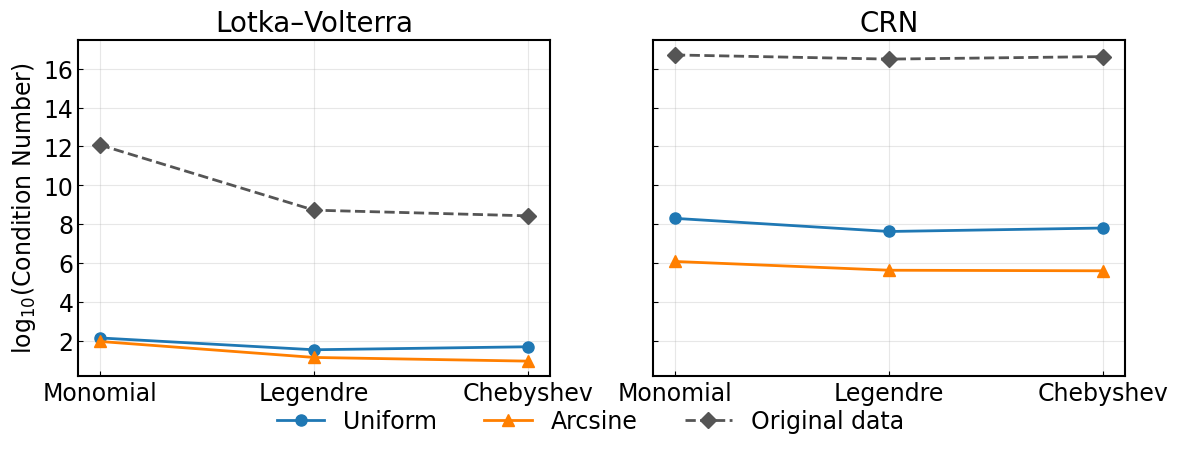

In [ ]:
basis_order = ['Monomial', 'Legendre', 'Chebyshev']

original_lib_cond_lv  = {b: vals[-1] for b, vals in lv_ori.items()}
original_lib_cond_crn = {b: vals[-1] for b, vals in crn_ori.items()}


libraries = ['Monomial', 'Legendre', 'Chebyshev']
x = np.arange(len(libraries))

lv_series = {
    'Uniform':     uniform_conds_lv,
    'Arcsine':     arcsine_conds_lv
    #'Exponential': exp_conds_lv,
}
crn_series = {
    'Uniform':     uniform_conds_crn,
    'Arcsine':     arcsine_conds_crn
    #'Exponential': exp_conds_crn,
}

# markers for distributions
#markers = {'Uniform':'o', 'Arcsine':'^', 'Exponential':'s'}
markers = {'Uniform':'o', 'Arcsine':'^'}

# colors: sample=dark
colors_sample = {
    'Uniform':     '#1F78B4',  # blue (dark)
    'Arcsine':     '#FF7F00'  # orange (dark)
    #'Exponential': '#33A02C',  # green (dark)
}

# Original style
orig_color  = '#555555'
orig_marker = 'D'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# -------- LV --------
for label, y in lv_series.items():
    #y_arr = np.asarray(y, dtype=float)[:len(libraries)]
    axes[0].plot(
        x, y,
        color=colors_sample[label],
        linestyle='-', linewidth=2,
        marker=markers[label], markersize=8,
        label=label, zorder=3
    )

# Original data
lv_orig_vals = [original_lib_cond_lv[b] for b in libraries]
axes[0].plot(
    x, lv_orig_vals,
    color=orig_color,
    linestyle='--', linewidth=2,
    marker=orig_marker, markersize=8,
    label='Original data (deg 5)', zorder=2
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(libraries, fontsize=17)
axes[0].set_ylabel('log$_{10}$(Condition Number)', fontsize=17)
axes[0].set_title('Lotka–Volterra', fontsize=20)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='both', labelsize=17)
axes[0].yaxis.set_major_locator(MaxNLocator(integer=False))

# -------- CRN --------
for label, y in crn_series.items():
    axes[1].plot(
        x, y,
        color=colors_sample[label],
        linestyle='-', linewidth=2,
        marker=markers[label], markersize=8,
        label=label, zorder=3
    )

# Original data
crn_orig_vals = [original_lib_cond_crn[b] for b in libraries]
axes[1].plot(
    x, crn_orig_vals,
    color=orig_color,
    linestyle='--', linewidth=2,
    marker=orig_marker, markersize=8,
    label='Original data (deg 5)', zorder=2
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(libraries, fontsize=17)
axes[1].set_title('CRN', fontsize=20)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='both', labelsize=17)

# Legend
sample_handles = [
    Line2D([0],[0], color=colors_sample['Uniform'],     marker=markers['Uniform'],
           lw=2, linestyle='-', markersize=8, label='Uniform'),
    Line2D([0],[0], color=colors_sample['Arcsine'],     marker=markers['Arcsine'],
           lw=2, linestyle='-', markersize=8, label='Arcsine')
]

orig_handle = Line2D(
    [0],[0],
    color=orig_color, marker=orig_marker,
    lw=2, linestyle='--', markersize=8,
    label='Original data'
)

all_handles = sample_handles + [orig_handle]

fig.legend(
    handles=all_handles,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
    fontsize=17
)

fig.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

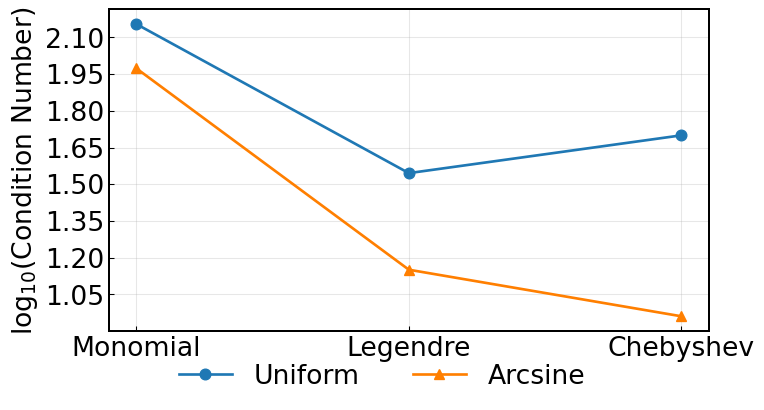

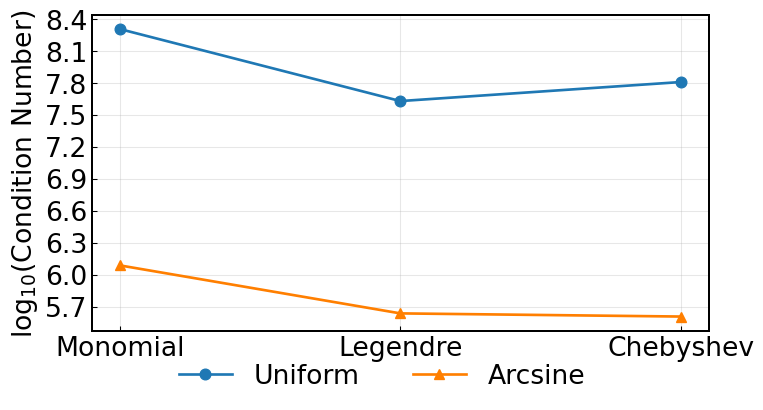

In [ ]:
font_size = 20
dpi = 96
basis_order = ['Monomial', 'Legendre', 'Chebyshev']

#original_lib_cond_lv  = {b: vals[-1] for b, vals in lv_ori.items()}
#original_lib_cond_crn = {b: vals[-1] for b, vals in crn_ori.items()}

libraries = ['Monomial', 'Legendre', 'Chebyshev']
x = np.arange(len(libraries))

lv_series = {
    'Uniform':     uniform_conds_lv,
    'Arcsine':     arcsine_conds_lv
}
crn_series = {
    'Uniform':     uniform_conds_crn,
    'Arcsine':     arcsine_conds_crn
}

# markers for distributions
markers = {'Uniform': 'o', 'Arcsine': '^'}

# colors: sample=dark
colors_sample = {
    'Uniform': '#1F78B4',  # blue (dark)
    'Arcsine': '#FF7F00',  # orange (dark)
}

# Original data style
#orig_color  = '#555555'
#orig_marker = 'D'


all_y = []

# LV sample-based
for y in lv_series.values():
    y_arr = np.asarray(y, dtype=float)[:len(libraries)]
    all_y.extend(y_arr)

# CRN sample-based
for y in crn_series.values():
    y_arr = np.asarray(y, dtype=float)[:len(libraries)]
    all_y.extend(y_arr)

# LV original
#lv_orig_vals  = [original_lib_cond_lv[b]  for b in libraries]
#crn_orig_vals = [original_lib_cond_crn[b] for b in libraries]
#all_y.extend(lv_orig_vals)
#all_y.extend(crn_orig_vals)

#y_min = min(all_y)
#y_max = max(all_y)

#y_margin = 0.05 * (y_max - y_min)
#y_lim = (y_min - y_margin, y_max + y_margin)

# Lotka-Volterra
fig1, ax1 = plt.subplots(figsize=(8.2677, 4.8031), dpi=dpi)


for label, y in lv_series.items():
    y_arr = np.asarray(y, dtype=float)[:len(libraries)]
    ax1.plot(
        x, y_arr,
        color=colors_sample[label],
        linestyle='-', linewidth=2,
        marker=markers[label], markersize=8,
        label=label, zorder=3
    )

#ax1.plot(
    #x, lv_orig_vals,
    #color=orig_color,
    #linestyle='--', linewidth=2,
    #marker=orig_marker, markersize=8,
    #label='Original data', zorder=2
#)

ax1.set_xticks(x)
ax1.set_xticklabels(libraries, fontsize=font_size)
ax1.set_ylabel('log$_{10}$(Condition Number)', fontsize=font_size)
#ax1.set_title('Lotka–Volterra', fontsize=25, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=font_size)
ax1.yaxis.set_major_locator(MaxNLocator(integer=False))
#ax1.set_ylim(y_lim)

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
fig1.legend(
    handles=handles1,
    labels=labels1,
    loc='lower center',
    ncol=len(handles1),
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
    fontsize=20
)
fig1.tight_layout(rect=[0, 0.08, 1, 0.95])
fig1.savefig(out_path_plots2 / "Cond_lib_LV.png", dpi=dpi, 
             bbox_inches="tight", pad_inches=0.02)
plt.show()

# CRN
fig2, ax2 = plt.subplots(figsize=(8.2677, 4.8031), dpi=dpi)

for label, y in crn_series.items():
    y_arr = np.asarray(y, dtype=float)[:len(libraries)]
    ax2.plot(
        x, y_arr,
        color=colors_sample[label],
        linestyle='-', linewidth=2,
        marker=markers[label], markersize=8,
        label=label, zorder=3
    )

#ax2.plot(
 #   x, crn_orig_vals,
 #   color=orig_color,
 #   linestyle='--', linewidth=2,
 #   marker=orig_marker, markersize=8,
 #   label='Original data', zorder=2
#)

ax2.set_xticks(x)
ax2.set_xticklabels(libraries, fontsize=font_size)
ax2.set_ylabel('log$_{10}$(Condition Number)', fontsize=font_size)
#ax2.set_title('CRN', fontsize=25, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=font_size)
ax2.yaxis.set_major_locator(MaxNLocator(integer=False))
#ax2.set_ylim(y_lim)

handles2, labels2 = ax2.get_legend_handles_labels()
fig2.legend(
    handles=handles2,
    labels=labels2,
    loc='lower center',
    ncol=len(handles2),
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
    fontsize=font_size
)
fig2.tight_layout(rect=[0, 0.08, 1, 0.95])
fig2.savefig(out_path_plots2 / "Cond_lib_CRN.png", dpi=dpi, 
             bbox_inches="tight", pad_inches=0.02)

plt.show()

Plot 3: Number of wrong equations

Chemical Reaction Network

Uniform distribution

(37,5)/(36,10) is enough for 5-lib. (20,5) is enough for 4-lib. Previous

In [245]:
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/CRN")
out_path = dir / "IC_uniform"
k_rates = {"k":2.12456, "kr":1.10124, "kcat":1.5093}
num = 35

start = 0
end = 0.01
n_step = 10  # actually n-1 steps

Sample = sampling(data, num, distribution='uniform',noise_level=None)
L, U = Sample.L_orig, Sample.U_orig

filepaths = Sample.fit_and_save_base(
    model_name='CRN',
    out_path=out_path,
    start=start,
    end=end,
    n_step=n_step,
    k_rates=k_rates,
    method='Legendre',
    noise_level=None
)

uniform_sample_crn = Sample._subsample(filepaths, L, U)
uniform_sample_crn['time'] = range(1, len(uniform_sample_crn) + 1)

time_col = 'time' 
state_cols_crn = [col for col in uniform_sample_crn.columns if col != 'time' and '/dt' and 'dt' not in col] 
states_with_time_cols_crn = [time_col] + state_cols_crn
derivative_cols_crn = [f'd{col}/dt' for col in state_cols_crn]

uniform_data_time_states_crn = uniform_sample_crn[states_with_time_cols_crn]
uniform_subsample_states_crn = uniform_sample_crn[state_cols_crn]
uniform_subsample_derivatives_crn = uniform_sample_crn[derivative_cols_crn]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'x4', 'dx1/dt', 'dx2/dt', 'dx3/dt', 'dx4/dt']


In [246]:
# Uniform distribution test

Test = distribution_test(uniform_subsample_states_crn)
# 1) Marginal distribution（each dimension）
marginals = Test.chi2_uniform_marginals(bounds=None, k=None, min_exp=5)
for r in marginals:
    print(f"dim {r['dim']}: chi2={r['stat']:.2f}, df={r['df']}, p={r['pvalue']:.4g}, bins={r['k']}")

# 2) Joint distribution (2,3,4)
joint = Test.chi2_uniform_joint(bounds=None, k=None, min_exp=5)
print(f"JOINT: chi2={joint['stat']:.2f}, df={joint['df']}, p={joint['pvalue']:.4g}, "
      f"k={joint['k']} -> cells={np.prod(joint['observed_shape'])}")

dim 0: chi2=22.74, df=13, p=0.04487, bins=16
dim 1: chi2=21.94, df=13, p=0.05625, bins=16
dim 2: chi2=31.89, df=13, p=0.002498, bins=16
dim 3: chi2=22.74, df=13, p=0.04487, bins=16
JOINT: chi2=106.63, df=7, p=4.591e-20, k=2 -> cells=16


In [247]:
degree = 5
threshold = 1e-1
after_threshold = 1.0
min = data_states.min()
max = data_states.max()
#Legendre_sampled = Recover_Model_sindy(df_used_to_deriv,differential_order=2,poly_degree=degree,
    #threshold=threshold,Xdot=uniform_subsample_derivatives,method='Legendre',after_threshold=None)
Legendre_sampled = Recover_Model_sindy(uniform_data_time_states_crn,differential_order=2,poly_degree=degree,
    threshold=threshold,Xdot=uniform_subsample_derivatives_crn,method='Legendre',after_threshold=after_threshold,
    L=min, U=max,denormalize=True)

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8000012926685568, 1.4448790623606422, 1.4448790623606416, 0.5714323142942984]
b (vector): [-1.000003231671392, -3.334609900078892, -1.0000272870030331, -1.0]
A^(-1) (diagonal): [1.2499979802086436, 0.692099446971154, 0.6920994469711543, 1.7499885375487902]
[AFTER-THRESH] filtered 22 term(s) in dx1/dt with threshold=1.0
[AFTER-THRESH] filtered 85 term(s) in dx2/dt with threshold=1.0
[AFTER-THRESH] filtered 85 term(s) in dx3/dt with threshold=1.0
[AFTER-THRESH] filtered 1 term(s) in dx4/dt with threshold=1.0


In [248]:
Legendre_sampled.model_expression

,Variable,Equation
0,dx1/dt,-2.111 x1 x2 + 1.072 x3
1,dx2/dt,1.829 x1 x2^3 + 1.305 x1 x2^2 x3 - 5.796 x1 x2...
2,dx3/dt,-1.829 x1 x2^3 - 1.305 x1 x2^2 x3 + 5.796 x1 x...
3,dx4/dt,1.510 x3


In [178]:
degree = 5
threshold = 1e-3
after_threshold = 1.0
min = data_states.min()
max = data_states.max()
#Legendre_sampled = Recover_Model_sindy(df_used_to_deriv,differential_order=2,poly_degree=degree,
    #threshold=threshold,Xdot=uniform_subsample_derivatives,method='Legendre',after_threshold=None)
Legendre_sampled_orig = Recover_Model_sindy(data,differential_order=2,poly_degree=degree,
    threshold=threshold,Xdot=None,method='Monomial',after_threshold=after_threshold,
    L=min, U=max,denormalize=False)

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
[AFTER-THRESH][Monomial] filtered 16 term(s) in dx1/dt with threshold=1.0
[AFTER-THRESH][Monomial] filtered 3 term(s) in dx2/dt with threshold=1.0
[AFTER-THRESH][Monomial] filtered 3 term(s) in dx3/dt with threshold=1.0
[AFTER-THRESH][Monomial] filtered 6 term(s) in dx4/dt with threshold=1.0


In [179]:
Legendre_sampled_orig.model_expression

,Varaiable,Equation
0,dx1/dt,6.611 x1^5 - 18.616 x1^4 x3 - 5.879 x1^4 x4 + ...
1,dx2/dt,-29.625 x1^5 - 12.698 x1^4 x2 + 83.790 x1^4 x3...
2,dx3/dt,29.625 x1^5 + 12.698 x1^4 x2 - 83.790 x1^4 x3 ...
3,dx4/dt,-12.178 x1^5 + 5.385 x1^4 x2 + 36.427 x1^4 x4 ...


In [66]:
# degree = 5
uniform_monomial_wrong_crn = 4
uniform_Legendre_wrong_crn = 0
uniform_Chebyshev_wrong_crn = 2
uniform_Laguerre_wrong_crn = 4
uniform_wrong_crn = [
    uniform_monomial_wrong_crn,
    uniform_Legendre_wrong_crn,
    uniform_Chebyshev_wrong_crn
]


uniform_monomial_wrong_crn_orig = 4
uniform_Legendre_wrong_crn_orig = 4
uniform_Chebyshev_wrong_crn_orig = 4
uniform_Laguerre_wrong_crn_orig = 4
uniform_wrong_crn_orig = [
    uniform_monomial_wrong_crn_orig,
    uniform_Legendre_wrong_crn_orig,
    uniform_Chebyshev_wrong_crn_orig
]

Arcsine distribution

(41,10)|(40,5) is enough for up to 5-lib, (27,10) is enough for 4-lib

In [181]:
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/CRN")
out_path = dir / "IC_arcsine"
k_rates = {"k":2.12456, "kr":1.10124, "kcat":1.5093}
num = 41

start = 0
end = 0.01
n_step = 5  # actually n-1 steps

Sample = sampling(data, num, distribution='arcsine',noise_level=None)
L, U = Sample.L_orig, Sample.U_orig

filepaths = Sample.fit_and_save_base(
    model_name='CRN',
    out_path=out_path,
    start=start,
    end=end,
    n_step=n_step,
    k_rates=k_rates,
    method='Chebyshev',
    noise_level=None
)

arcsine_sample_crn = Sample._subsample(filepaths, L, U)
arcsine_sample_crn['time'] = range(1, len(arcsine_sample_crn) + 1)

arcsine_data_time_states_crn = arcsine_sample_crn[states_with_time_cols_crn]
arcsine_subsample_states_crn = arcsine_sample_crn[state_cols_crn]
arcsine_subsample_derivatives_crn = arcsine_sample_crn[derivative_cols_crn]

Subsample input columns: ['time', 'x1', 'x2', 'x3', 'x4', 'dx1/dt', 'dx2/dt', 'dx3/dt', 'dx4/dt']


/Users/yuxiangfeng/Desktop/SINDy/3.Dependence/illposed_env/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning:

invalid value encountered in log



In [182]:
# arcsine distribution test

Test = distribution_test(arcsine_subsample_states_crn)
# 1) Marginal distribution（each dimension）
marginal_res = Test.ks_arcsine_marginals(bounds=None)
for r in marginal_res:
    print(f"dim {r['dim']}: KS D={r['stat']:.4f}, p={r['pvalue']:.4g}, n={r['n']}, {r['note']}")

# 2) Joint distribution (2,3,4)
joint_res = Test.energy_arcsine_joint(bounds=None, n_ref=1000, n_perm=999, random_state=27, max_pool=4000)
print(joint_res)

dim 0: KS D=0.0398, p=0.9856, n=123, bounds estimated
dim 1: KS D=0.0669, p=0.6168, n=123, bounds estimated
dim 2: KS D=0.0939, p=0.2141, n=123, bounds estimated
dim 3: KS D=0.0585, p=0.7713, n=123, bounds estimated
{'stat': 0.10741640062428044, 'pvalue': 0.335, 'n': 123, 'm': 1000, 'bounds': [(-0.9974923983011927, 0.9750899831609656), (-1.052882977525571, 1.014797869806464), (-0.9907120904274939, 1.063604118403298), (-0.9972460286156586, 1.006369431715247)], 'note': 'bounds estimated from sample; permutations=999; pooled=1123/1123'}


In [189]:
degree = 5
threshold = 1e-1
after_threshold = 0.1
min = data_states.min()
max = data_states.max()
#Legendre_sampled = Recover_Model_sindy(df_used_to_deriv,differential_order=2,poly_degree=degree,
    #threshold=threshold,Xdot=uniform_subsample_derivatives,method='Legendre',after_threshold=None)
Chebyshev_sampled = Recover_Model_sindy(arcsine_data_time_states_crn,differential_order=2,poly_degree=degree,
    threshold=threshold,Xdot=arcsine_subsample_derivatives_crn,method='Chebyshev',after_threshold=after_threshold,
    L=min, U=max,denormalize=True)

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8000012926685568, 1.4448790623606422, 1.4448790623606416, 0.5714323142942984]
b (vector): [-1.000003231671392, -3.334609900078892, -1.0000272870030331, -1.0]
A^(-1) (diagonal): [1.2499979802086436, 0.692099446971154, 0.6920994469711543, 1.7499885375487902]
[AFTER-THRESH] filtered 3 term(s) in dx1/dt with threshold=0.1
[AFTER-THRESH] filtered 41 term(s) in dx2/dt with threshold=0.1
[AFTER-THRESH] filtered 41 term(s) in dx3/dt with threshold=0.1
[AFTER-THRESH] filtered 1 term(s) in dx4/dt with threshold=0.1


In [190]:
Chebyshev_sampled.model_expression

,Variable,Equation
0,dx1/dt,-2.125 x1 x2 + 1.102 x3
1,dx2/dt,-2.148 x1 x2 + 2.596 x3
2,dx3/dt,2.148 x1 x2 - 2.596 x3
3,dx4/dt,1.510 x3


In [128]:
degree = 5
threshold = 1e-2
after_threshold = 8e-1
min = data_states.min()
max = data_states.max()
#Legendre_sampled = Recover_Model_sindy(df_used_to_deriv,differential_order=2,poly_degree=degree,
    #threshold=threshold,Xdot=uniform_subsample_derivatives,method='Legendre',after_threshold=None)
Chebyshev_sampled_orig = Recover_Model_sindy(data_normalized,differential_order=2,poly_degree=degree,
    threshold=threshold,Xdot=None,method='Chebyshev',after_threshold=after_threshold,
    L=min, U=max,denormalize=True)

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8000000000000459, 2.0000000000013403, 2.0000000000013367, 0.571428571428704]
b (vector): [-1.0000000000001148, -5.000000000002681, -1.0000000000013367, -1.0]
A^(-1) (diagonal): [1.2499999999999283, 0.49999999999966493, 0.4999999999996658, 1.749999999999594]


In [129]:
Chebyshev_sampled_orig.model_expression

,Variable,Equation
0,dx1/dt,1429.780 x1^4 + 1063.480 x1^3 x2 - 1056.507 x1...
1,dx2/dt,-5532.723 x1^3 x2 + 5491.046 x1^3 x3 + 11086.2...
2,dx3/dt,5532.723 x1^3 x2 - 5491.046 x1^3 x3 - 11086.28...
3,dx4/dt,-13289.974 x1^4 - 3232.015 x1^3 x2 + 3204.669 ...


In [67]:
# degree = 5
arcsine_monomial_wrong_crn = 4
arcsine_Legendre_wrong_crn = 2
arcsine_Chebyshev_wrong_crn = 0
arcsine_Laguerre_wrong_crn = 4
arcsine_wrong_crn = [
    arcsine_monomial_wrong_crn,
    arcsine_Legendre_wrong_crn,
    arcsine_Chebyshev_wrong_crn
]


arcsine_monomial_wrong_crn_orig = 4
arcsine_Legendre_wrong_crn_orig = 4
arcsine_Chebyshev_wrong_crn_orig = 4
arcsine_Laguerre_wrong_crn_orig = 4
arcsine_wrong_crn_orig = [
    arcsine_Legendre_wrong_crn_orig,
    arcsine_Legendre_wrong_crn_orig,
    arcsine_Chebyshev_wrong_crn_orig
]

Lotka-Volterra Model

Uniform Distribution

(43,5) is enough for 5-lib

In [ ]:
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/Lotka-Volterra")
out_path = dir / "IC_uniform"
num = 43

start = 0
end = 0.05
n_step = 5  # actually n-1 steps

Sample = sampling(data_lv, num, distribution='uniform',noise_level=None)
L, U = Sample.L_orig, Sample.U_orig

filepaths = Sample.fit_and_save_base(
    model_name='Lotka-Volterra',
    out_path=out_path,
    start=start,
    end=end,
    n_step=n_step,
    params = params,
    method='Legendre',
    noise_level=None
)

uniform_sample_lv = Sample._subsample(filepaths, L, U)
uniform_sample_lv['time'] = range(1, len(uniform_sample_lv) + 1)

time_col = 'time' 
state_cols_lv = [col for col in uniform_sample_lv.columns if col != 'time' and '/dt' and 'dt' not in col] 
states_with_time_cols_lv = [time_col] + state_cols_lv
derivative_cols_lv = [f'd{col}/dt' for col in state_cols_lv]

uniform_data_time_states_lv = uniform_sample_lv[states_with_time_cols_lv]
uniform_subsample_states_lv = uniform_sample_lv[state_cols_lv]
uniform_subsample_derivatives_lv = uniform_sample_lv[derivative_cols_lv]

In [ ]:
# Uniform distribution test

Test = distribution_test(uniform_subsample_states_lv)
# 1) Marginal distribution（each dimension）
marginals = Test.chi2_uniform_marginals(bounds=None, k=None, min_exp=5)
for r in marginals:
    print(f"dim {r['dim']}: chi2={r['stat']:.2f}, df={r['df']}, p={r['pvalue']:.4g}, bins={r['k']}")

# 2) Joint distribution (2,3,4)
joint = Test.chi2_uniform_joint(bounds=None, k=None, min_exp=5)
print(f"JOINT: chi2={joint['stat']:.2f}, df={joint['df']}, p={joint['pvalue']:.4g}, "
      f"k={joint['k']} -> cells={np.prod(joint['observed_shape'])}")

In [ ]:
degree = 5
threshold = 1e-2
after_threshold = 0.08
min = data_states_lv.min()
max = data_states_lv.max()
#Legendre_sampled = Recover_Model_sindy(df_used_to_deriv,differential_order=2,poly_degree=degree,
    #threshold=threshold,Xdot=uniform_subsample_derivatives,method='Legendre',after_threshold=None)
Legendre_sampled = Recover_Model_sindy(uniform_data_time_states_lv,differential_order=2,poly_degree=degree,
    threshold=threshold,Xdot=uniform_subsample_derivatives_lv,method='Chebyshev',after_threshold=after_threshold,
    L=min, U=max,denormalize=True)

In [ ]:
Legendre_sampled.model_expression

In [ ]:
degree = 5
threshold = 1e-3
after_threshold = 0.08
min = data_states_lv.min()
max = data_states_lv.max()
#Legendre_sampled = Recover_Model_sindy(df_used_to_deriv,differential_order=2,poly_degree=degree,
    #threshold=threshold,Xdot=uniform_subsample_derivatives,method='Legendre',after_threshold=None)
Legendre_orig = Recover_Model_sindy(data_lv,differential_order=2,poly_degree=degree,
    threshold=threshold,method='Chebyshev',after_threshold=after_threshold,
    L=min, U=max,denormalize=True)

In [ ]:
Legendre_orig.model_expression

In [68]:
# degree = 5
uniform_monomial_wrong_lv = 3
uniform_Legendre_wrong_lv = 0
uniform_Chebyshev_wrong_lv = 1
uniform_Laguerre_wrong_lv = 3
uniform_wrong_lv = [
    uniform_monomial_wrong_lv,
    uniform_Legendre_wrong_lv,
    uniform_Chebyshev_wrong_lv
]


uniform_monomial_wrong_lv_orig = 3
uniform_Legendre_wrong_lv_orig = 3
uniform_Chebyshev_wrong_lv_orig = 3
uniform_Laguerre_wrong_lv_orig = 3
uniform_wrong_lv_orig = [
    uniform_monomial_wrong_lv_orig,
    uniform_Legendre_wrong_lv_orig,
    uniform_Chebyshev_wrong_lv_orig
]

Arcsine distribution

(24,5) is enough for 5-lib

In [ ]:
dir = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/Lotka-Volterra")
out_path = dir / "IC_arcsine"
num = 24

start = 0
end = 0.05
n_step = 5  # actually n-1 steps

Sample = sampling(data_lv, num, distribution='arcsine',noise_level=None)
L, U = Sample.L_orig, Sample.U_orig

filepaths = Sample.fit_and_save_base(
    model_name='Lotka-Volterra',
    out_path=out_path,
    start=start,
    end=end,
    n_step=n_step,
    params = params,
    method='Chebyshev',
    noise_level=None
)

arcsine_sample_lv = Sample._subsample(filepaths, L, U)
arcsine_sample_lv['time'] = range(1, len(arcsine_sample_lv) + 1)

arcsine_data_time_states_lv = arcsine_sample_lv[states_with_time_cols_lv]
arcsine_subsample_states_lv = arcsine_sample_lv[state_cols_lv]
arcsine_subsample_derivatives_lv = arcsine_sample_lv[derivative_cols_lv]

In [ ]:
# arcsine distribution test

Test = distribution_test(arcsine_subsample_states_lv)
# 1) Marginal distribution（each dimension）
marginal_res = Test.ks_arcsine_marginals(bounds=None)
for r in marginal_res:
    print(f"dim {r['dim']}: KS D={r['stat']:.4f}, p={r['pvalue']:.4g}, n={r['n']}, {r['note']}")

# 2) Joint distribution (2,3,4)
joint_res = Test.energy_arcsine_joint(bounds=None, n_ref=1000, n_perm=999, random_state=27, max_pool=4000)
print(joint_res)

In [ ]:
degree = 5
threshold = 1e-2
after_threshold = 0.08
min = data_states_lv.min()
max = data_states_lv.max()
#Legendre_sampled = Recover_Model_sindy(df_used_to_deriv,differential_order=2,poly_degree=degree,
    #threshold=threshold,Xdot=uniform_subsample_derivatives,method='Legendre',after_threshold=None)
Chebyshev_sampled = Recover_Model_sindy(arcsine_data_time_states_lv,differential_order=2,poly_degree=degree,
    threshold=threshold,Xdot=arcsine_subsample_derivatives_lv,method='Chebyshev',after_threshold=after_threshold,
    L=min, U=max,denormalize=True)

In [ ]:
Chebyshev_sampled.model_expression

In [69]:
# degree = 5
arcsine_monomial_wrong_lv = 3
arcsine_Legendre_wrong_lv = 0
arcsine_Chebyshev_wrong_lv = 0
arcsine_Laguerre_wrong_lv = 3
arcsine_wrong_lv = [
    arcsine_monomial_wrong_lv,
    arcsine_Legendre_wrong_lv,
    arcsine_Chebyshev_wrong_lv
]


arcsine_monomial_wrong_lv_orig = 3
arcsine_Legendre_wrong_lv_orig = 3
arcsine_Chebyshev_wrong_lv_orig = 3
arcsine_Laguerre_wrong_lv_orig = 3
arcsine_wrong_lv_orig = [
    arcsine_monomial_wrong_lv_orig,
    arcsine_Legendre_wrong_lv_orig,
    arcsine_Chebyshev_wrong_lv_orig
]

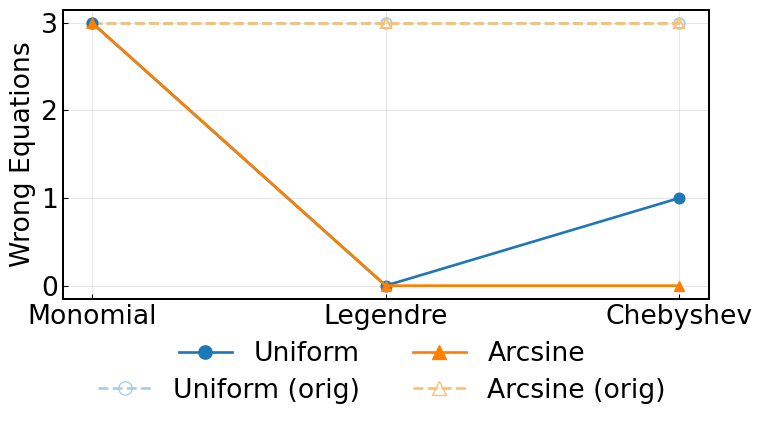

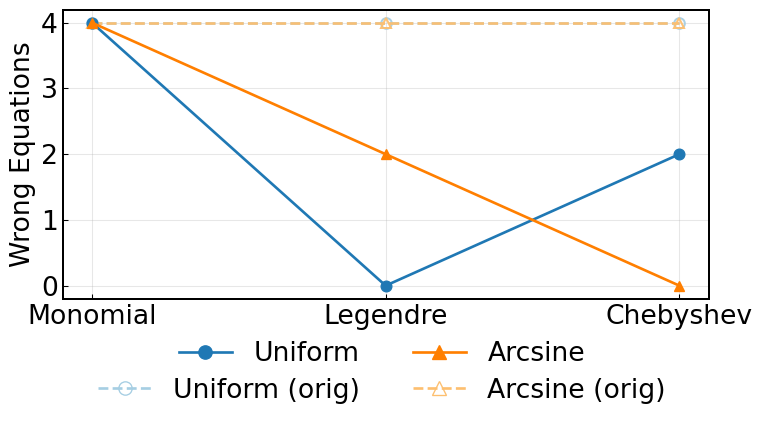

In [ ]:
libraries = ['Monomial', 'Legendre', 'Chebyshev']
x = np.arange(len(libraries))

# ---- sample ----
wrong_lv_series = {
    'Uniform':     uniform_wrong_lv,
    'Arcsine':     arcsine_wrong_lv,
}
wrong_crn_series = {
    'Uniform':     uniform_wrong_crn,
    'Arcsine':     arcsine_wrong_crn,
}

# ---- original ----
wrong_lv_series_orig = {
    'Uniform':     uniform_wrong_lv_orig,
    'Arcsine':     arcsine_wrong_lv_orig,
}
wrong_crn_series_orig = {
    'Uniform':     uniform_wrong_crn_orig,
    'Arcsine':     arcsine_wrong_crn_orig,
}

# Distribution - marker
markers = {'Uniform': 'o', 'Arcsine': '^'}
# Distribution - color (sample dark, orig light)
colors_sample = {
    'Uniform':  '#1F78B4',  
    'Arcsine':  '#FF7F00',  
}
colors_orig = {
    'Uniform':  '#A6CEE3',  
    'Arcsine':  '#FDBF6F',  
}

def plot_panel(ax, series_sample, series_orig, title):
    # Sample data: dark solid line + solid marker
    for label, y in series_sample.items():
        ax.plot(
            x, y,
            color=colors_sample[label],
            marker=markers[label], markersize=8,
            linestyle='-', linewidth=2,
            label=label, zorder=3
        )
    # Original data: light color dashed line + hollow marker
    for label, y in series_orig.items():
        ax.plot(
            x, y,
            color=colors_orig[label],
            marker=markers[label], markersize=8,
            markerfacecolor='none',
            markeredgecolor=colors_orig[label],
            markeredgewidth=1.5,
            linestyle='--', linewidth=2, alpha=0.95,
            label=f'{label} (orig)', zorder=2
        )

    ax.set_xticks(x)
    ax.set_xticklabels(libraries, fontsize=font_size)
    ax.set_ylabel('Wrong Equations', fontsize=font_size)
    #ax.set_title(title, fontsize=25, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=font_size)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))


def make_figure(series_sample, series_orig, title):
    fig, ax = plt.subplots(figsize=(8.2677, 4.8031), dpi=96)

    plot_panel(ax, series_sample, series_orig, title)

    fig.subplots_adjust(bottom=0.25)

    # Legend：top sample，bottom orig
    sample_handles = [
        Line2D([0], [0],
               color=colors_sample['Uniform'], marker=markers['Uniform'],
               lw=2, linestyle='-', markersize=10, label='Uniform'),
        Line2D([0], [0],
               color=colors_sample['Arcsine'], marker=markers['Arcsine'],
               lw=2, linestyle='-', markersize=10, label='Arcsine'),
    ]
    orig_handles = [
        Line2D([0], [0],
               color=colors_orig['Uniform'], marker=markers['Uniform'],
               lw=2, linestyle='--', markersize=10,
               mfc='none', mec=colors_orig['Uniform'],
               label='Uniform (orig)'),
        Line2D([0], [0],
               color=colors_orig['Arcsine'], marker=markers['Arcsine'],
               lw=2, linestyle='--', markersize=10,
               mfc='none', mec=colors_orig['Arcsine'],
               label='Arcsine (orig)'),
    ]

    # labels
    sample_labels = [h.get_label() for h in sample_handles]
    orig_labels   = [h.get_label() for h in orig_handles]

    # First row: sample data
    fig.legend(
        handles=sample_handles, labels=sample_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.10),  
        ncol=3,
        frameon=False,
        fontsize=font_size
    )

    # Second row: original data
    fig.legend(
        handles=orig_handles, labels=orig_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.02),   
        ncol=3,
        frameon=False,
        fontsize=font_size
    )

    fig.tight_layout(rect=[0, 0.18, 1, 0.98])
    return fig, ax


# 1) Lotka–Volterra
fig_lv, ax_lv = make_figure(
    wrong_lv_series,
    wrong_lv_series_orig,
    title='Lotka–Volterra'
)
fig_lv.savefig(out_path_plots2 / "wrong_eqs_LV.png", dpi=dpi, 
             bbox_inches="tight", pad_inches=0.02)

# 2) CRN
fig_crn, ax_crn = make_figure(
    wrong_crn_series,
    wrong_crn_series_orig,
    title='CRN'
)
fig_crn.savefig(out_path_plots2 / "wrong_eqs_CRN.png", dpi=dpi, 
             bbox_inches="tight", pad_inches=0.02)

plt.show()
